# GEDI / OBIWAN Biomass & Carbon Accounting over LULC Transitions

Runs **after** `Postprocess_Transition_Attribution` and `Full_Workflow_VM0047_DualTemporal_Optimized`.
It estimates **Above-Ground Biomass Density (AGBD)** and **carbon (tCO2e/ha)** *per LULC transition
class*, with **statistical uncertainty**, using GEDI L4A footprints and a **design-based stratified
estimator** in the spirit of the **OBIWAN** API — explicitly *not* a naive pixel-difference of two
biomass maps.

### References
- OBIWAN app: https://yang.users.earthengine.app/view/obiwan
- Method/UI: https://estimatingbiomasschange.vercel.app/
- Code logic: https://github.com/gyan1201/Estimating-Biomass-Change-with-GEDI-and-the-OBIWAN-API
- GEDI L4A (footprints): `LARSE/GEDI/GEDI04_A_002_MONTHLY` · GEDI L4B (gridded): `LARSE/GEDI/GEDI04_B_002`

### Why design-based, not pixel subtraction
A pixel-by-pixel difference of two interpolated AGBD maps confounds **model error** with real change
and yields **no defensible uncertainty**. GEDI is a *sample* of lidar footprints. OBIWAN treats the
footprints inside a domain as a statistical sample and reports a **mean AGBD with a standard error**;
change is the **difference of two means** with **propagated variance** — `Var(Δ)=Var₁+Var₂`.

### The hybrid variance we compute (heavily commented in code)
For footprints i=1..n in a stratum/year with AGBD `yᵢ` (Mg/ha) and footprint model SE `uᵢ` (`agbd_se`):
```
ȳ      = mean(yᵢ)                          # estimated mean AGBD
v_samp = s² / n,  s² = sample variance      # design-based SAMPLING variance of the mean (SRS)
v_pred = mean(uᵢ²) / n                       # GEDI MODEL prediction-error contribution
SE     = sqrt(v_samp + v_pred)               # hybrid standard error of the mean
95% CI = ȳ ± 1.96·SE
```
This is a transparent **hybrid of the design-based sampling variance and the GEDI model variance**
(Patterson et al. 2019; Dubayah L4B ATBD). The full OBIWAN/L4B estimator additionally folds in the
model **coefficient covariance** (a systematic term needing the published model covariance matrix);
here that term is approximated by the per-footprint prediction variances `uᵢ²`. *(Swap in the exact
covariance term if you have it — the code marks exactly where.)*

> **Temporal scope:** GEDI exists from **2019**. Per your choice, **all estimates are GEDI-era only
> (2019–2024)**; transition classes act as **spatial strata**. Pre-2019 biomass is *not* inferred.


# VM0047 Eligibility Check — Optimized Dual-Temporal Forest Analysis (L9 / L8 / S2)

Consolidated & optimized from `Full_Workflow_VM0047_Eligibility_Check_L8_S2.ipynb`.

**Layout (hybrid):** reusable helper functions are defined once in the *"Helpers"* cells, then the
analysis is **run step-by-step in visible cells** — you execute a cell, inspect its printed stats /
DataFrame, and move on, exactly like the original notebook. The same helpers are reused for
$T_0$ and $T_{-10}$, so there is **no duplicated logic**, only short visible run-cells per epoch.

### How to run
1. Run **Phase 0** (setup) and the **Global Configuration** cell.
2. Run **Phase 1** (RoI).
3. Run the **Helpers** cells (they only *define* functions — no heavy compute).
4. Run the **T0 run** cells in order, inspecting each output.
5. Run the **T-10 run** cells in order.
6. Run **Change detection → Report → Visualization → Export**.

### Optimization principles
No client-side loops over collections · `.reproject()` only in the majority filter · deferred
`Map.addLayer` · server-side coverage ratio · date-capped datasets (nearest available year) ·
every `reduceRegion` bounded with `bestEffort` + `tileScale` + `maxPixels`.

```mermaid
graph TD
    A[RoI, T0 Year, processMultiFeatures] --> P1(Phase 1: RoI)
    P1 --> P2(Phase 2: Sensor + Coverage L9->L8->S2)
    P2 --> P3(Phase 3: Masks GFC/DW/Canopy + Embeddings)
    P3 --> P4(Phase 4: Train -> Classify -> Smooth)
    P4 --> CD(Change Detection T-10 vs T0)
    CD --> P5(Phase 5: Accuracy OA/Kappa)
    P5 --> P6(Phase 6: Markdown Report)
```


In [ ]:
# ---------------------------------------------------------------
# 0) Imports, logging, Earth Engine initialization
# ---------------------------------------------------------------
import ee, geemap
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from datetime import datetime
import logging, time, random, os, re, json
from pathlib import Path

try:
    import seaborn as sns
    sns.set_theme(context="notebook", style="whitegrid")
except Exception:
    sns = None

PROJECT_ID = "ee-geocaptain"
EE_API_URL = "https://earthengine-highvolume.googleapis.com"

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(message)s", datefmt="%H:%M:%S")

def init_ee(project_id=None, api_url=None, retries=3, sleep_base=1.5):
    """Initialize Earth Engine with retries and a tiny session ping."""
    for i in range(retries):
        try:
            ee.Initialize(project=project_id, opt_url=api_url) if api_url \
                else ee.Initialize(project=project_id)
            ee.Number(1).getInfo()
            logging.info("Earth Engine initialized."); return
        except Exception as e:
            logging.warning("EE init failed (%d/%d): %s", i + 1, retries, e)
            if i == retries - 1: raise
            time.sleep(sleep_base * (i + 1))

def safe_get_info(obj, label="object", retries=1):
    """getInfo with retries. USE ONLY on small objects (scalars / tiny dicts)."""
    for i in range(retries + 1):
        try:
            return obj.getInfo()
        except Exception as e:
            logging.warning("safe_get_info failed for %s (%d/%d): %s", label, i+1, retries+1, e)
            time.sleep(1.2 * (i + 1))
    return None

class StepTimer:
    """Context manager to time/audit a step."""
    def __init__(self, name="step"): self.name = name
    def __enter__(self): self.t0 = time.time(); logging.info("> %s ...", self.name); return self
    def __exit__(self, *a):
        dt = time.time() - self.t0
        logging.info("%s %s in %.2fs", "x" if a[0] else "v", self.name, dt)

random.seed(30)
with StepTimer("EE initialization"):
    # ee.Authenticate()   # <-- uncomment on first run in a new environment
    init_ee(PROJECT_ID, EE_API_URL)
START_TIME = time.time()
print("ee", getattr(ee, "__version__", "?"), "| geemap", getattr(geemap, "__version__", "?"))


In [ ]:
# ===============================================================
# GLOBAL CONFIGURATION  (edit here only)
# ===============================================================
# ---- RoI (Phase 1) ----
SHAPEFILE_PATH         = "data_roi/GUA_reddeslocales.shp"   # local .shp (+ .shx/.dbf/.prj)
PROCESS_MULTI_FEATURES = False     # False = single feature; True = dissolved union of ALL features
TARGET_FEATURE_ID      = 3      # single-feature mode: select feature whose 'fid' == this (e.g. 2); None = first
BUFFER_DISTANCE_M      = 90       # +expand / -shrink RoI (m); 0 = none

# ---- Temporal design (Phase 4) ----
T0_YEAR     = 2022                 # present epoch
EPOCH_GAP   = 7                   # T-10 = T0 - EPOCH_GAP
START_MONTH = 1                    # seasonal window
END_MONTH   = 12                   # 12 = full calendar year

# ---- Sensors / coverage (Phase 2) ----
CLOUD_COVER_MAX = 40               # max scene cloud % admitted
COVERAGE_TARGET = 0.99             # best single scene >= this -> use it, else median composite

# ---- Masks / feature space (Phase 3) ----
HANSEN_ASSET      = "UMD/hansen/global_forest_change_2025_v1_13"
GFC_TREECOVER_MIN = 15
USE_DYNAMIC_WORLD = True
DW_MIN_YEAR       = 2015
DW_MIN_COVER_FRAC = 0.30
EXCLUDE_WATER_SNOW= True
USE_CANOPY_HEIGHT = True
CANOPY_IC_ID      = "projects/sat-io/open-datasets/facebook/meta-canopy-height"
CH_FOREST_MIN_M   = 7
USE_EMBEDDINGS    = True           # 64 AlphaEarth bands -> heaviest step; set False if memory-bound
EMBED_IC_ID       = "GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL"
EMBED_MIN_YEAR    = 2017
EMBED_MAX_YEAR    = 2024

# ---- Training / classification (Phase 4) ----
NUM_TRAINING_POINTS = 300
NONFOREST_BOOST     = 1.2
METHOD              = "RF"         # "RF" | "KNN" | "CKMEANS"
RF_PARAMS           = dict(numberOfTrees=300, minLeafPopulation=1, bagFraction=0.6, seed=30)
KNN_PARAMS          = dict(k=7)
CKMEANS_PARAMS      = dict(nClusters=2, maxIter=50)

# ---- Smoothing ----
SMOOTH_TARGET_SCALE = 30
SMOOTH_WINDOW_PX    = 5
SMOOTH_FOREST_PROP  = 0.60
SMOOTH_MIN_NEIGHBOR = 0.10

# ---- Accuracy (Phase 5) : types 'internal' | 'hansen' | 'asset' ----
VALIDATION_LAYERS = [
    {"name": "Internal stratified hold-out", "type": "internal", "n_per_class": 100},
    {"name": "Hansen GFC (treecover2000)",   "type": "hansen"},
    # {"name": "MapBiomas Colombia 2024", "type": "asset", "kind": "image",
    #  "asset_id": "projects/ee-tu-usuario/assets/mapbiomas_colombia_2024",
    #  "band": "classification", "forest_values": [1, 3, 4, 5, 6]},
    # {"name": "IDEAM Bosque 2023", "type": "asset", "kind": "image",
    #  "asset_id": "users/tu_usuario/ideam_bosque_2023", "band": "b1", "forest_values": [1]},
]

# ---- Reporting / export ----
OUTPUT_DIR      = "GUA/"
EXPORT_TO_DRIVE = True
EXPORT_SCALE    = 30
EXPORT_CRS      = "EPSG:4326"

# ---- Phase 9: independent transition rasters (Hansen GFW + MapBiomas) ----
PHASE9_SCALE               = 30        # export scale (m) for both transition rasters
EXPORT_PHASE9              = True      # build & export the Hansen + MapBiomas transitions

# MapBiomas is multi-country/collection. Preferred path = catalog JSON + country (auto-resolves the
# integration asset, the latest collection, and the available year range for that country).
MAPBIOMAS_CATALOG_JSON     = "data_roi/mapbiomas_catalog.json"
MAPBIOMAS_COUNTRY          = "guatemala"   # brazil, amazon, chaco, colombia, peru, bolivia, ecuador, ...
MAPBIOMAS_COLLECTION       = None         # None = use the catalog's 'latest' for that country
MAPBIOMAS_FOREST_CLASS_IDS = [3, 4, 5, 6, 49]   # forest classes (legend: 3 Forest, 4 Savanna, 5 Mangrove,
                                                #  6 Flooded forest, 49 Wooded sandbank) - adjust per legend
# Integration assets are single Images with per-year bands 'classification_YYYY':
MAPBIOMAS_BAND_TEMPLATE    = "classification_{year}"
MAPBIOMAS_CLASS_BAND       = "classification"
# Fallback (used only if the catalog/country cannot be resolved):
MAPBIOMAS_ASSET            = "projects/mapbiomas-public/assets/colombia/collection3/mapbiomas_colombia_collection3_integration_v1"
MAPBIOMAS_KIND             = "image"      # "image" (classification_YYYY bands) | "collection"
MAPBIOMAS_MIN_YEAR         = 1985         # fallback year window if catalog not used
MAPBIOMAS_MAX_YEAR         = 2024

# ---- Cartography ----
CLASS_NAMES   = {0: "Other", 1: "Forest", 2: "Non-forest"}
CLASS_PALETTE = ["2ca25f", "de2d26"]   # 1=forest, 2=non-forest

T10_YEAR = T0_YEAR - EPOCH_GAP
print(f"Dual-temporal -> T0={T0_YEAR} | T-10={T10_YEAR} | classifier={METHOD}")
print(f"RoI: {SHAPEFILE_PATH} | processMultiFeatures={PROCESS_MULTI_FEATURES}")


In [ ]:
# ---------------------------------------------------------------
# 1) Load AOI shapefile -> ee.FeatureCollection, resolve working region
# ---------------------------------------------------------------
def load_aoi_featurecollection(shapefile_path):
    """Read shapefile, reproject to EPSG:4326, return (FeatureCollection, GeoDataFrame, path)."""
    if not os.path.exists(shapefile_path):
        cands = list(Path(".").rglob(Path(shapefile_path).name))
        if cands: shapefile_path = str(cands[0]); logging.info("Found by search: %s", shapefile_path)
        else: raise FileNotFoundError(f"Shapefile not found: {shapefile_path} (cwd={os.getcwd()})")
    base = os.path.splitext(shapefile_path)[0]
    miss = [e for e in (".shx", ".dbf", ".prj") if not os.path.exists(base + e)]
    if miss: logging.warning("Missing sidecar files: %s", ", ".join(miss))
    gdf = gpd.read_file(shapefile_path)
    if gdf.empty: raise ValueError("Shapefile has no geometries.")
    if gdf.crs is None: gdf.set_crs(epsg=4326, inplace=True)
    gdf = gdf.to_crs(epsg=4326)
    feats = []
    for idx, row in gdf.iterrows():
        g = row.geometry
        if g is None or g.is_empty: continue
        if not g.is_valid: g = g.buffer(0)
        feats.append(ee.Feature(ee.Geometry(g.__geo_interface__), {"fid": int(idx)}))
    if not feats: raise ValueError("No valid features after cleaning.")
    return ee.FeatureCollection(feats), gdf, shapefile_path

def get_region_of_interest(fc, process_multi_features, buffer_m=0, target_feature_id=None):
    """
    process_multi_features=True  -> dissolved union of ALL features.
    process_multi_features=False -> a single feature:
        * if target_feature_id is given -> the feature whose 'fid' property equals it
          (aoi_fc.filter(ee.Filter.eq('fid', target_feature_id)));
        * otherwise -> the first feature.
    Optional buffer is applied last. Returns an ee.Geometry.
    """
    if process_multi_features:
        region = fc.geometry()                                  # server-side dissolve / union
    elif target_feature_id is not None:
        sel = fc.filter(ee.Filter.eq("fid", target_feature_id))
        if int(safe_get_info(sel.size(), "target feature") or 0) == 0:
            raise ValueError(f"No feature with fid={target_feature_id} in the shapefile "
                             f"(available fids: {sorted(aoi_gdf.index.tolist())}).")
        region = ee.Feature(sel.first()).geometry()
    else:
        region = ee.Feature(fc.first()).geometry()
    return region.buffer(buffer_m) if buffer_m else region

with StepTimer("Phase 1 - RoI"):
    aoi_fc, aoi_gdf, SHAPEFILE_PATH = load_aoi_featurecollection(SHAPEFILE_PATH)
    region = get_region_of_interest(aoi_fc, PROCESS_MULTI_FEATURES, BUFFER_DISTANCE_M, TARGET_FEATURE_ID)
    n_feats = int(safe_get_info(aoi_fc.size(), "aoi size") or 0)
    area_ha = safe_get_info(region.area(1).divide(1e4), "roi area") or 0.0

if PROCESS_MULTI_FEATURES:
    sel_desc = "union of all features"
elif TARGET_FEATURE_ID is not None:
    sel_desc = f"single feature fid={TARGET_FEATURE_ID}"
else:
    sel_desc = "first feature"
print(f"Features: {n_feats} | selection: {sel_desc}")
print(f"Working RoI area: {area_ha:,.1f} ha (buffer {BUFFER_DISTANCE_M} m)")
display(aoi_gdf.head())


## Phase 9 — Export Catalog: Hansen (GFW) & MapBiomas transitions

Two **independent, dataset-native** multitemporal transition rasters for the same $T_{-10}\rightarrow T_0$
window, built directly from authoritative products (no classifier involved) and exported to Drive.
Both use the **identical class scheme** as the model-based change map:

| code | meaning |
|------|---------|
| 11 | stable forest |
| 22 | stable non-forest |
| 12 | forest → non-forest (loss / deforestation) |
| 21 | non-forest → forest (gain / regeneration) |

- **Hansen GFC** — `treecover2000` + `lossyear` + `loss` + `gain`; loss is restricted to the
  $(T_{-10}, T_0]$ window via `lossyear`. (Hansen's `gain` band is period-limited to 2000–2012 and
  carries no year, so gain is flagged as *any* gain occurrence — a known dataset limitation.)
- **MapBiomas** — annual forest masks via a configurable `MapBiomas` class; **any** forest↔non-forest
  flip across consecutive years in the window flags loss/gain. Years are clamped to the dataset window.

This phase honours `PROCESS_MULTI_FEATURES` (works on the dissolved union) and names outputs by
**Feature ID** when a single feature is selected, or **`Dissolved_ROI`** when the union is processed.

In [ ]:
# ---------------------------------------------------------------
# 9.1) Definitions: Hansen transition + MapBiomas class
# ---------------------------------------------------------------
TRANSITION_CLASS_NAMES = {11: "Stable forest", 22: "Stable non-forest",
                          12: "Forest -> Non-forest (loss)", 21: "Non-forest -> Forest (gain)"}

def hansen_transition(roi, t0, t10, treecover_min=GFC_TREECOVER_MIN):
    """
    Hansen GFC transition (T-10 -> T0). Bands: treecover2000, lossyear, loss, gain.
    Returns a byte image with classes {11, 22, 12, 21}, masked elsewhere, clipped to roi.
    """
    gfc      = ee.Image(HANSEN_ASSET)
    tc       = gfc.select("treecover2000")
    lossyear = gfc.select("lossyear").unmask(0)     # 0 = none; y -> loss in year 2000+y
    loss     = gfc.select("loss").unmask(0)
    gain     = gfc.select("gain").unmask(0)         # forest gain 2000-2012 (period-limited)
    off10, off0 = int(t10) - 2000, int(t0) - 2000

    # Forest standing at T-10: forest in 2000 AND not already lost by T-10.
    forest2000      = tc.gte(treecover_min)
    loss_before_t10 = lossyear.gte(1).And(lossyear.lte(off10))
    forest_t10      = forest2000.And(loss_before_t10.Not())
    nonforest_t10   = forest_t10.Not()

    # Loss strictly inside (T-10, T0]; gain = any occurrence (year not resolvable in Hansen).
    loss_window = loss.eq(1).And(lossyear.gt(off10)).And(lossyear.lte(off0))
    gain_window = gain.eq(1)

    h_loss = forest_t10.And(loss_window)
    h_gain = nonforest_t10.And(gain_window)

    transition = (ee.Image(0)
        .where(forest_t10.And(h_loss.Not()), 11)
        .where(nonforest_t10.And(h_gain.Not()), 22)
        .where(h_loss, 12)
        .where(h_gain, 21)
        .rename("Hansen_Transition").toByte())
    return transition.updateMask(transition.neq(0)).clip(roi)


class MapBiomas:
    """
    Multi-country/collection MapBiomas integration.

    Construct directly with an asset, or (preferred) via `MapBiomas.from_catalog(json, country, ...)`
    which resolves the country's integration asset, latest collection and year range from a catalog
    JSON (see data_roi/mapbiomas_catalog.json).

    Asset kinds:
      * kind='image'      -> a single ee.Image with per-year bands like 'classification_YYYY'
                             (this is the MapBiomas 'integration' format),
      * kind='collection' -> an annual ee.ImageCollection (filtered by year, select class band).
    forest_class_ids define which class codes count as forest.
    """
    def __init__(self, asset_id, forest_class_ids, kind="image",
                 band_template="classification_{year}", class_band="classification",
                 min_year=None, max_year=None, country=None, collection=None):
        self.asset_id = asset_id
        self.forest_ids = list(forest_class_ids)
        self.kind = kind
        self.band_template = band_template
        self.class_band = class_band
        self.min_year = min_year
        self.max_year = max_year
        self.country = country
        self.collection = collection
        self._img = ee.Image(asset_id) if kind == "image" else None
        self._ic  = ee.ImageCollection(asset_id) if kind == "collection" else None

    # ---------- JSON catalog helpers ----------
    @staticmethod
    def _looks_like_asset(s):
        """True if a string looks like a GEE asset path (projects/... or users/...)."""
        return (isinstance(s, str) and "/" in s and " " not in s.strip()
                and s.split("/", 1)[0] in ("projects", "users"))

    @staticmethod
    def _walk_collect(obj, parent=None):
        """Recursively yield (key, value, parent_container) for every node in dicts/lists."""
        if isinstance(obj, dict):
            for k, v in obj.items():
                yield k, v, obj
                yield from MapBiomas._walk_collect(v, obj)
        elif isinstance(obj, list):
            for i, v in enumerate(obj):
                yield i, v, obj
                yield from MapBiomas._walk_collect(v, obj)

    def _extract_integration_assets_from_json(self, json_path):
        """Extract MapBiomas *integration* asset IDs from a JSON catalog file."""
        if not os.path.exists(json_path):
            raise FileNotFoundError(json_path)
        with open(json_path, "r", encoding="utf-8") as f:
            try:
                data = json.load(f)
            except Exception as e:
                raise ValueError(f"Invalid JSON at {json_path}: {e}")

        assets = []
        for k, v, parent in self._walk_collect(data):
            if isinstance(k, str) and k.lower() == "integration" and isinstance(v, str) and self._looks_like_asset(v):
                assets.append(v)
        if not assets:
            for k, v, p in self._walk_collect(data):
                if isinstance(v, str) and "/integration" in v and self._looks_like_asset(v):
                    assets.append(v)
        if not assets:
            for k, v, p in self._walk_collect(data):
                if isinstance(v, str) and self._looks_like_asset(v):
                    assets.append(v)

        seen, out = set(), []
        for a in assets:
            if a not in seen:
                seen.add(a); out.append(a)
        if not out:
            raise ValueError("No MapBiomas integration assets found in JSON.")
        return out

    @classmethod
    def list_countries(cls, json_path):
        """Return the country keys available in the catalog (without the 'mapbiomas-' prefix)."""
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        return sorted(k.replace("mapbiomas-", "") for k in data if str(k).startswith("mapbiomas-"))

    @classmethod
    def from_catalog(cls, json_path, country, forest_class_ids, collection=None,
                     kind="image", band_template="classification_{year}", class_band="classification"):
        """
        Resolve a country's MapBiomas integration asset + year range from the catalog JSON.
        'country' accepts 'colombia' or 'mapbiomas-colombia' (case-insensitive).
        """
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        ckey = country if str(country).lower().startswith("mapbiomas-") else f"mapbiomas-{str(country).strip().lower()}"
        keys = {k.lower(): k for k in data}
        if ckey.lower() not in keys:
            raise ValueError(f"Country '{country}' not in catalog. Available: {cls.list_countries(json_path)}")
        entry = data[keys[ckey.lower()]]
        coll = collection or entry.get("latest")
        colls = entry.get("collections", {})
        if coll not in colls:
            raise ValueError(f"Collection '{coll}' not found for {ckey}. Available: {list(colls)}")
        node = colls[coll]
        asset = (node.get("assets", {}) or {}).get("integration")
        if not asset or not cls._looks_like_asset(asset):
            raise ValueError(f"No valid integration asset for {ckey}/{coll}.")
        years = [int(y) for y in (node.get("periods", {}).get("Coverage", []) or []) if str(y).isdigit()]
        lo, hi = (min(years), max(years)) if years else (None, None)
        return cls(asset, forest_class_ids, kind=kind, band_template=band_template,
                   class_band=class_band, min_year=lo, max_year=hi, country=ckey, collection=coll)

    # ---------- core LULC access ----------
    def classification(self, year):
        """Return the single-band classification image for 'year'."""
        if self.kind == "image":
            return self._img.select(self.band_template.format(year=int(year)))
        s = ee.Date.fromYMD(int(year), 1, 1)
        e = ee.Date.fromYMD(int(year), 12, 31).advance(1, "day")
        return ee.Image(self._ic.filterDate(s, e).first()).select(self.class_band)

    def mapbiomas_forest_mask(self, year, forest_class_ids=None):
        """Forest mask (1=forest, 0=non-forest) for 'year' (optimized remap, no per-class .Or loop)."""
        ids = list(forest_class_ids) if forest_class_ids is not None else self.forest_ids
        cls = self.classification(year)
        return cls.remap(ids, [1] * len(ids), 0).rename("forest_mask").toByte()

    def transition(self, roi, t0, t10):
        """
        Annual transitions across [t10, t0]; flag ANY loss/gain occurrence between consecutive years.
        Each yearly mask is computed once (optimization over the original double-call loop).
        Returns a byte image with classes {11, 22, 12, 21}, masked elsewhere, clipped to roi.
        """
        years = list(range(int(t10), int(t0) + 1))
        masks = {y: self.mapbiomas_forest_mask(y).clip(roi) for y in years}     # compute once each
        forest_t10    = masks[years[0]]
        nonforest_t10 = forest_t10.Not()
        has_loss, has_gain = ee.Image(0), ee.Image(0)
        for y in years[:-1]:
            cur, nxt = masks[y], masks[y + 1]
            has_loss = has_loss.Or(cur.eq(1).And(nxt.eq(0)))
            has_gain = has_gain.Or(cur.eq(0).And(nxt.eq(1)))
        mb_loss = forest_t10.eq(1).And(has_loss)
        mb_gain = forest_t10.eq(0).And(has_gain)
        transition = (ee.Image(0)
            .where(forest_t10.eq(1).And(mb_loss.Not()), 11)
            .where(forest_t10.eq(0).And(mb_gain.Not()), 22)
            .where(mb_loss, 12)
            .where(mb_gain, 21)
            .rename("MapBiomas_Transition").toByte())
        return transition.updateMask(transition.neq(0)).clip(roi)


def phase9_roi_tag():
    """Dynamic output name component: Feature ID, or 'Dissolved_ROI' for the union."""
    if PROCESS_MULTI_FEATURES:
        return "Dissolved_ROI"
    if TARGET_FEATURE_ID is not None:
        return f"fid{TARGET_FEATURE_ID}"
    return "fid0"

print("Phase 9 definitions ready -> hansen_transition(), MapBiomas class, tag:", phase9_roi_tag())


Phase 9 definitions ready -> hansen_transition(), MapBiomas class, tag: fid3


In [ ]:
# ---------------------------------------------------------------
# 9.2) Build both transition rasters + quick area tables
# ---------------------------------------------------------------
# Hansen (always available) -- restricted to the (T-10, T0] window.
with StepTimer("Phase 9 - Hansen transition"):
    hansen_tx = hansen_transition(region, T0_YEAR, T10_YEAR)
print(f"Hansen GFC transition {T10_YEAR} -> {T0_YEAR} | areas (ha):")
try:
    display(df_class_area(hansen_tx, region, PHASE9_SCALE, names=TRANSITION_CLASS_NAMES))
except Exception as ex:
    print("  area summary skipped:", ex)

# MapBiomas -- catalog-driven (country -> integration asset + year range); skip gracefully on failure.
mb_tx, mb, mb_t0, mb_t10 = None, None, None, None
with StepTimer("Phase 9 - MapBiomas transition"):
    try:
        if MAPBIOMAS_CATALOG_JSON and os.path.exists(MAPBIOMAS_CATALOG_JSON) and MAPBIOMAS_COUNTRY:
            mb = MapBiomas.from_catalog(MAPBIOMAS_CATALOG_JSON, MAPBIOMAS_COUNTRY,
                                        MAPBIOMAS_FOREST_CLASS_IDS, collection=MAPBIOMAS_COLLECTION,
                                        kind="image", band_template=MAPBIOMAS_BAND_TEMPLATE,
                                        class_band=MAPBIOMAS_CLASS_BAND)
            print(f"MapBiomas catalog -> {mb.country} / {mb.collection} | years {mb.min_year}-{mb.max_year}")
            print(f"  asset: {mb.asset_id}")
        else:
            mb = MapBiomas(MAPBIOMAS_ASSET, MAPBIOMAS_FOREST_CLASS_IDS, kind=MAPBIOMAS_KIND,
                           band_template=MAPBIOMAS_BAND_TEMPLATE, class_band=MAPBIOMAS_CLASS_BAND,
                           min_year=MAPBIOMAS_MIN_YEAR, max_year=MAPBIOMAS_MAX_YEAR)
            print(f"MapBiomas fallback asset: {mb.asset_id}")
        # Clamp T-10 / T0 to the dataset's available coverage years.
        lo = mb.min_year if mb.min_year is not None else MAPBIOMAS_MIN_YEAR
        hi = mb.max_year if mb.max_year is not None else MAPBIOMAS_MAX_YEAR
        mb_t0  = nearest_available_year(T0_YEAR,  lo, hi)
        mb_t10 = nearest_available_year(T10_YEAR, lo, hi)
        mb_tx = mb.transition(region, mb_t0, mb_t10)
        _ = int(safe_get_info(mb_tx.bandNames().size(), "mb bands") or 0)   # surface asset errors early
    except Exception as ex:
        mb_tx = None
        print("MapBiomas skipped:", ex)
        print("  -> check MAPBIOMAS_CATALOG_JSON / MAPBIOMAS_COUNTRY / *_FOREST_CLASS_IDS in the config.")
        try:
            print("  Available countries:", MapBiomas.list_countries(MAPBIOMAS_CATALOG_JSON))
        except Exception:
            pass
if mb_tx is not None:
    print(f"MapBiomas transition {mb_t10} -> {mb_t0} | areas (ha):")
    try:
        display(df_class_area(mb_tx, region, PHASE9_SCALE, names=TRANSITION_CLASS_NAMES))
    except Exception as ex:
        print("  area summary skipped:", ex)

# Defer visualization: add to the Phase 7 map if it exists (kept off by default).
try:
    tx_vis = {"min": 11, "max": 22, "palette": ["#1a9850", "#fdae61", "#d73027", "#4575b4"]}
    if "Map" in globals():
        Map.addLayer(hansen_tx, tx_vis, f"Hansen transition {phase9_roi_tag()}", False)
        if mb_tx is not None:
            Map.addLayer(mb_tx, tx_vis, f"MapBiomas transition {phase9_roi_tag()}", False)
except Exception:
    pass


11:27:35 | INFO | > Phase 9 - Hansen transition ...
11:27:35 | INFO | v Phase 9 - Hansen transition in 0.00s


Hansen GFC transition 2015 -> 2022 | areas (ha):


,class,label,area_ha,pct
0,11,Stable forest,209124.912383,80.41
1,22,Stable non-forest,34430.599629,13.24
2,12,Forest -> Non-forest (loss),15947.635779,6.13
3,21,Non-forest -> Forest (gain),558.172266,0.21


11:27:42 | INFO | > Phase 9 - MapBiomas transition ...
11:27:42 | INFO | v Phase 9 - MapBiomas transition in 0.05s


MapBiomas skipped: Country 'guatemala' not in catalog. Available: ['amazon', 'argentina', 'atlantic-forest', 'bolivia', 'brazil', 'chaco', 'chile', 'colombia', 'ecuador', 'indonesia', 'pampa', 'paraguay', 'peru', 'uruguay', 'venezuela']
  -> check MAPBIOMAS_CATALOG_JSON / MAPBIOMAS_COUNTRY / *_FOREST_CLASS_IDS in the config.
  Available countries: ['amazon', 'argentina', 'atlantic-forest', 'bolivia', 'brazil', 'chaco', 'chile', 'colombia', 'ecuador', 'indonesia', 'pampa', 'paraguay', 'peru', 'uruguay', 'venezuela']


In [ ]:
# ---------------------------------------------------------------
# 9.3) Export Hansen & MapBiomas transition rasters to Google Drive
# ---------------------------------------------------------------
_folder = EXPORT_FOLDER if "EXPORT_FOLDER" in globals() else f"GEE_VM0047_{T0_YEAR}"
if EXPORT_PHASE9:
    tag = phase9_roi_tag()
    jobs = [(hansen_tx, f"Hansen_Transition_{T10_YEAR}_{T0_YEAR}_{tag}")]
    if mb_tx is not None:
        jobs.append((mb_tx, f"MapBiomas_Transition_{mb_t10}_{mb_t0}_{tag}"))
    for img, desc in jobs:
        try:
            ee.batch.Export.image.toDrive(
                image=img.clip(region), description=desc, folder=_folder,
                region=region, scale=PHASE9_SCALE, maxPixels=1e13,
                crs=EXPORT_CRS, fileFormat="GeoTIFF").start()
            print("Started export:", desc)
        except Exception as ex:
            print(f"  x {desc} skipped: {ex}")
    print(f"-> Drive folder '{_folder}'. Monitor in the EE 'Tasks' tab.")
else:
    print("EXPORT_PHASE9 = False -> transition rasters built but not exported.")


Started export: Hansen_Transition_2015_2022_fid3
-> Drive folder 'GEE_VM0047_GUA_reddeslocales_2022'. Monitor in the EE 'Tasks' tab.


In [ ]:
# ---- Elapsed time ----
elapsed = time.time() - START_TIME
h, rem = divmod(int(elapsed), 3600); m, s = divmod(rem, 60)
print(f"Total notebook execution time: {h}h {m}m {s}s")


Total notebook execution time: 0h 20m 27s


## Phase 0 — Setup & Configuration

Earth Engine init + the single configuration block. **`TRANSITION_SOURCE`** selects which local
transition raster is used as the stratification layer.

In [17]:
# ------------------------------------------------------------------
# 0a) Imports + Earth Engine init
# ------------------------------------------------------------------
import os, sys, math, glob, logging, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns; sns.set_theme(context="notebook", style="whitegrid")
except Exception:
    sns = None

import ee
try:
    import geemap
except Exception:
    geemap = None

import rasterio
import geopandas as gpd

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s",
                    datefmt="%H:%M:%S")

PROJECT_ID = "ee-geocaptain"
EE_API_URL = "https://earthengine-highvolume.googleapis.com"
def init_ee():
    try:
        ee.Initialize(project=PROJECT_ID, opt_url=EE_API_URL); ee.Number(1).getInfo()
        logging.info("Earth Engine initialized.")
    except Exception as e:
        logging.warning("EE init: %s -> trying default", e)
        ee.Initialize(project=PROJECT_ID)
# ee.Authenticate()   # uncomment on first run
init_ee()


02:14:17 | WARNING | Sleeping 0.71 seconds before retry 1 of 5 for request: GET https://earthengine-highvolume.googleapis.com/$discovery/rest?version=v1&prettyPrint=false, after ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
02:14:19 | INFO | Earth Engine initialized.


In [74]:
# ------------------------------------------------------------------
# 0b) CONFIGURATION  (edit here)
# ------------------------------------------------------------------
# ---- Stratification layer: choose ONE source (the parameter you asked for) ----
TRANSITION_SOURCES = {
    "RF":        "data_roi/transition_results/RF_Transition_2015_2025.tif",
    "Hansen":    "data_roi/transition_results/Hansen_Transition_2015_2025.tif",
    "MapBiomas": "data_roi/transition_results/MapBiomas_Transition_2014_2024_ROI.tif",
}
TRANSITION_SOURCE = "Hansen"                       # <-- switch to "RF", "Hansen" / "MapBiomas" as needed
TRANSITION_RASTER = TRANSITION_SOURCES[TRANSITION_SOURCE]

# ---- AOI (dissolved parcels) ----
AOI_SHAPEFILE = "data_roi/KEN_pwc_expansion.shp"

# ---- Transition legend (strata) ----
KEEP_CLASSES = (11, 22, 12, 21)
CLASS_LABELS = {11: "Stable forest", 22: "Stable non-forest",
                12: "Forest -> Non-forest (loss)", 21: "Non-forest -> Forest (gain)"}

# ---- GEDI (L4A footprints) ----
GEDI_L4A         = "LARSE/GEDI/GEDI04_A_002_MONTHLY"
ANALYSIS_YEARS   = [2019, 2020, 2021, 2022, 2023, 2024]   # GEDI-era only
SENSITIVITY_MIN  = 0.95     # GEDI quality: beam sensitivity threshold
GEDI_SCALE       = 25       # L4A footprint grid (m)
MAX_FOOTPRINTS   = 50000    # client pull guard; above this -> export to Drive (see helper)

# ---- Change / additionality windows (within GEDI era) ----
CHANGE_YEARS    = (2019, 2024)     # mean(b) - mean(a)
BASELINE_PERIOD = (2019, 2021)     # historical rate
PROJECT_PERIOD  = (2021, 2024)     # project rate  -> additionality = project_rate - baseline_rate

# ---- Carbon conversion (IPCC) ----
CARBON_FRACTION = 0.47             # AGB d.m. -> C
CO2_PER_C       = 44.0 / 12.0      # C -> CO2e

# ---- Forecasting (IPCC Tier 1 tropical moist defaults; edit freely) ----
TRANSITION_WINDOW_YEARS = 10       # transition rasters span ~10 yr (2014/15 -> 2024/25)
GROWTH_INCREMENT_AGB    = 6.0      # Mg AGB ha-1 yr-1 natural regen (IPCC trop. moist, young)
AGB_MAX                 = 300.0    # Mg/ha mature AGB cap
ACCEL_LOSS_MULTIPLIER   = 1.5      # 'Accelerated harvesting' = 1.5x baseline loss rate
# Chapman-Richards restoration curve  AGB(t) = A*(1-exp(-k*t))^p
CR_A, CR_K, CR_P        = AGB_MAX, 0.05, 1.5
FORECAST_HORIZONS       = [10, 20] # years ahead to report

# ---- Task 3: single target transition + ECOLOGICAL CAPS ----
TARGET_TRANSITION = 22             # forecast/trend/baseline focus: ONE of 11, 22, 12, 21
# Accumulation CEILING (conservation/restoration cannot exceed mature-forest carbon):
CAP_MAX_CLASSES   = (22,11)       # CAP_MAX = max(mean AGBD over these classes)
# Degradation FLOOR (harvesting/degradation cannot drop below non-forest carbon):
FLOOR_MIN_CLASSES = (22,11)          # FLOOR_MIN = mean(mean AGBD over these classes)
# Trend estimator for the data-driven baseline (fit to the FULL multitemporal GEDI series):
TREND_METHOD = "wls"               # "wls" (SE-weighted) | "ols" (equal weights) | "theilsen" (robust)

# ---- Outputs ----
OUT_BIOMASS_DIR = "output/biomass"
OUT_TABLE_DIR   = "output/biomass"
os.makedirs(OUT_BIOMASS_DIR, exist_ok=True)

def agbd_to_co2e(agbd_mg_ha):
    """AGBD (Mg d.m./ha) -> tCO2e/ha  =  AGBD * 0.47 * 44/12  (linear; SE scales identically)."""
    return agbd_mg_ha * CARBON_FRACTION * CO2_PER_C

print(f"Stratification source: {TRANSITION_SOURCE} -> {TRANSITION_RASTER}")
print(f"GEDI years: {ANALYSIS_YEARS} | change {CHANGE_YEARS} | baseline {BASELINE_PERIOD} | project {PROJECT_PERIOD}")


Stratification source: Hansen -> data_roi/transition_results/Hansen_Transition_2015_2025.tif
GEDI years: [2019, 2020, 2021, 2022, 2023, 2024] | change (2019, 2024) | baseline (2019, 2021) | project (2021, 2024)


## Phase 1 — Task 1: GEDI L4A extraction (quality-filtered footprints)

Loads the dissolved AOI, then pulls **quality-filtered GEDI L4A footprints** per year into a local
GeoDataFrame. Quality mask = `l4_quality_flag==1` **and** `degrade_flag==0` **and**
`sensitivity ≥ SENSITIVITY_MIN` — the standard GEDI L4A screening the OBIWAN pipeline relies on.

In [75]:
# ------------------------------------------------------------------
# 1) GEDI L4A footprint extraction
# ------------------------------------------------------------------
def load_aoi_ee(shapefile):
    """Dissolved AOI as ee.Geometry (EPSG:4326) + the parcels GeoDataFrame."""
    gdf = gpd.read_file(shapefile)
    if gdf.crs is None:
        raise ValueError("AOI shapefile has no CRS.")
    gdf4326 = gdf.to_crs(4326)
    union = gdf4326.union_all() if hasattr(gdf4326, "union_all") else gdf4326.unary_union
    return ee.Geometry(union.__geo_interface__), gdf

def gedi_quality_mask(img):
    """Standard GEDI L4A screening; masks AGBD where quality fails."""
    q = img.select("l4_quality_flag").eq(1)
    d = img.select("degrade_flag").eq(0)
    s = img.select("sensitivity").gte(SENSITIVITY_MIN)
    return img.updateMask(q.And(d).And(s))

def gedi_year_footprints_fc(aoi, year):
    """Quality-masked AGBD/agbd_se footprints for one year, as an ee.FeatureCollection of points."""
    start = ee.Date.fromYMD(year, 1, 1)
    end   = ee.Date.fromYMD(year, 12, 31).advance(1, "day")
    col = (ee.ImageCollection(GEDI_L4A).filterBounds(aoi).filterDate(start, end).map(gedi_quality_mask))
    # mosaic the year's footprints; each valid 25 m pixel is one footprint
    img = col.select(["agbd", "agbd_se"]).mosaic()
    fc = img.sample(region=aoi, scale=GEDI_SCALE, projection="EPSG:4326",
                    geometries=True, dropNulls=True, tileScale=4)
    return fc.map(lambda f: f.set("year", year))

def fc_to_gdf(fc):
    """ee.FeatureCollection -> GeoDataFrame (geemap if available, else getInfo)."""
    n = int(fc.size().getInfo() or 0)
    if n == 0:
        return gpd.GeoDataFrame(columns=["agbd", "agbd_se", "year", "geometry"], geometry="geometry", crs=4326)
    if n > MAX_FOOTPRINTS:
        logging.warning("%d footprints > MAX_FOOTPRINTS=%d. Consider exporting to Drive instead.", n, MAX_FOOTPRINTS)
    if geemap is not None:
        try:
            return geemap.ee_to_gdf(fc)
        except Exception as e:
            logging.warning("geemap.ee_to_gdf failed (%s); falling back to getInfo.", e)
    info = fc.getInfo()
    from shapely.geometry import shape
    rows, geoms = [], []
    for ft in info["features"]:
        p = ft["properties"]; rows.append({"agbd": p.get("agbd"), "agbd_se": p.get("agbd_se"), "year": p.get("year")})
        geoms.append(shape(ft["geometry"]))
    return gpd.GeoDataFrame(rows, geometry=geoms, crs=4326)

AOI_EE, AOI_GDF = load_aoi_ee(AOI_SHAPEFILE)
parts = []
for y in ANALYSIS_YEARS:
    fc = gedi_year_footprints_fc(AOI_EE, y)
    g = fc_to_gdf(fc)
    logging.info("GEDI %d: %d footprints", y, len(g))
    if len(g): parts.append(g)
footprints = (gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), geometry="geometry", crs=4326)
              if parts else gpd.GeoDataFrame(columns=["agbd","agbd_se","year","geometry"], geometry="geometry", crs=4326))
print(f"Total quality footprints 2019-2024: {len(footprints)}")
display(footprints.head())


02:25:55 | WARNING | Sleeping 0.58 seconds before retry 1 of 5 for request: POST https://earthengine-highvolume.googleapis.com/v1/projects/ee-geocaptain/value:compute?prettyPrint=false&alt=json, after ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
02:25:57 | INFO | GEDI 2019: 410 footprints
02:25:58 | INFO | GEDI 2020: 71 footprints
02:26:00 | INFO | GEDI 2021: 1367 footprints
02:26:01 | INFO | GEDI 2022: 125 footprints
02:26:02 | INFO | GEDI 2023: 606 footprints
02:26:03 | INFO | GEDI 2024: 12 footprints


Total quality footprints 2019-2024: 2591


,geometry,agbd,agbd_se,year
0,POINT (34.90572 -1.23125),20.705013,17.132282,2019
1,POINT (34.90505 -1.23058),10.433659,17.141510,2019
2,POINT (34.89786 -1.22946),11.544752,17.140306,2019
3,POINT (34.89719 -1.22878),66.000694,17.124634,2019
4,POINT (34.89697 -1.22833),76.782013,17.124851,2019


## Phase 2 — Stratify footprints by the local transition raster

Each GEDI footprint is tagged with the **transition class** under it, sampled directly from the
**local** raster (`rasterio`, no GEE upload). Only footprints landing in `KEEP_CLASSES` are retained.

In [76]:
# ------------------------------------------------------------------
# 2) Stratify GEDI footprints with the chosen local transition raster
# ------------------------------------------------------------------
def stratify_footprints(footprints_gdf, raster_path, keep=KEEP_CLASSES):
    if footprints_gdf.empty:
        footprints_gdf["stratum"] = []
        return footprints_gdf
    with rasterio.open(raster_path) as src:
        pts = footprints_gdf.to_crs(src.crs)
        coords = [(geom.x, geom.y) for geom in pts.geometry]
        vals = [v[0] for v in src.sample(coords)]
    out = footprints_gdf.copy()
    out["stratum"] = [int(v) if v is not None else 0 for v in vals]
    out = out[out["stratum"].isin(keep)].copy()
    out["stratum_label"] = out["stratum"].map(CLASS_LABELS)
    return out

footprints_strat = stratify_footprints(footprints, TRANSITION_RASTER)
print("Footprints per stratum/year:")
if not footprints_strat.empty:
    display(footprints_strat.pivot_table(index="stratum_label", columns="year",
                                         values="agbd", aggfunc="count", fill_value=0))
else:
    print("No footprints intersected the kept transition classes.")


Footprints per stratum/year:


year,2019,2020,2021,2022,2023,2024
stratum_label,,,,,,
Forest -> Non-forest (loss),27,38,163,27,25,3
Non-forest -> Forest (gain),1,0,1,0,0,0
Stable forest,279,27,693,54,258,6
Stable non-forest,103,6,510,44,323,3


## Phase 3 — Task 2: Design-based estimators (the OBIWAN core)

`design_based_estimate` implements the hybrid mean/variance above. Everything downstream (annual
trend, change, additionality, carbon) is built from it, so the uncertainty propagates consistently.

In [77]:
# ------------------------------------------------------------------
# 3) Design-based hybrid estimator + per-(stratum,year) table
# ------------------------------------------------------------------
def design_based_estimate(y, u):
    """
    Hybrid design-based mean AGBD + standard error for one sample of footprints.
      y : array of footprint AGBD (Mg/ha)
      u : array of footprint model SE 'agbd_se' (Mg/ha)
    Returns dict with n, mean, se, 95% CI and the two variance components.

    MATH (see header):
      mean   = (1/n) Σ yᵢ
      v_samp = s²/n            with s² the *sample* variance (ddof=1)   -> design/sampling variance
      v_pred = mean(uᵢ²)/n                                              -> GEDI model variance term
      SE     = sqrt(v_samp + v_pred)
    NOTE: to use the EXACT OBIWAN/L4B hybrid, replace v_pred with the model-covariance term
          (a' C a) from the published GEDI L4A model covariance matrix C; the design term v_samp
          stays the same. The hook is marked below.
    """
    y = np.asarray(y, float); u = np.asarray(u, float)
    m = np.isfinite(y); y = y[m]; u = u[m] if u.shape == m.shape else u
    n = int(y.size)
    if n == 0:
        return dict(n=0, mean=np.nan, se=np.nan, ci_lo=np.nan, ci_hi=np.nan, v_samp=np.nan, v_pred=np.nan)
    mean = float(np.mean(y))
    v_samp = float(np.var(y, ddof=1) / n) if n >= 2 else 0.0
    u2 = u[np.isfinite(u)] ** 2 if np.isfinite(u).any() else np.array([0.0])
    v_pred = float(np.mean(u2) / n)                      # <-- OBIWAN/L4B exact: replace with a'C a
    v = v_samp + v_pred
    se = math.sqrt(v) if v > 0 else 0.0
    return dict(n=n, mean=mean, se=se, ci_lo=mean - 1.96 * se, ci_hi=mean + 1.96 * se,
                v_samp=v_samp, v_pred=v_pred)

def annual_stratum_table(strat_gdf):
    """Per (stratum, year): mean AGBD, SE, CI, n, and tCO2e/ha (mean & SE scaled)."""
    rows = []
    for (cls, yr), g in strat_gdf.groupby(["stratum", "year"]):
        est = design_based_estimate(g["agbd"].values, g["agbd_se"].values)
        rows.append({"stratum": cls, "stratum_label": CLASS_LABELS.get(cls, cls), "year": int(yr),
                     "n": est["n"], "agbd_mean": est["mean"], "agbd_se": est["se"],
                     "agbd_ci_lo": est["ci_lo"], "agbd_ci_hi": est["ci_hi"],
                     "co2e_mean": agbd_to_co2e(est["mean"]), "co2e_se": agbd_to_co2e(est["se"])})
    df = pd.DataFrame(rows).sort_values(["stratum", "year"]).reset_index(drop=True)
    return df

trend_df = annual_stratum_table(footprints_strat) if not footprints_strat.empty else pd.DataFrame()
print("Annual AGBD by stratum (Task 2 - Annual Biomass Trend):")
display(trend_df)


Annual AGBD by stratum (Task 2 - Annual Biomass Trend):


,stratum,stratum_label,year,n,agbd_mean,agbd_se,agbd_ci_lo,agbd_ci_hi,co2e_mean,co2e_se
0,11,Stable forest,2019,279,16.500825,1.384141,13.787909,19.213741,28.436422,2.385336
1,11,Stable forest,2020,27,66.672074,9.346520,48.352895,84.991252,114.898207,16.107169
2,11,Stable forest,2021,693,21.781806,1.146774,19.534130,24.029482,37.537312,1.976273
3,11,Stable forest,2022,54,65.858530,6.836586,52.458822,79.258238,113.496199,11.781716
4,11,Stable forest,2023,258,32.337598,2.229964,27.966869,36.708327,55.728461,3.842971
5,11,Stable forest,2024,6,18.383099,9.484895,-0.207294,36.973493,31.680208,16.345635
6,12,Forest -> Non-forest (loss),2019,27,52.253437,6.080884,40.334904,64.171970,90.050089,10.479390
7,12,Forest -> Non-forest (loss),2020,38,74.933733,6.952729,61.306383,88.561082,129.135800,11.981870
8,12,Forest -> Non-forest (loss),2021,163,59.967166,3.398517,53.306072,66.628260,103.343416,5.856778
9,12,Forest -> Non-forest (loss),2022,27,66.985899,9.625794,48.119342,85.852456,115.439032,16.588452


## Phase 4 — Task 2 cont.: Change (±95% CI), additionality & carbon stock

- **Change** between `CHANGE_YEARS` per stratum, with `Var(Δ)=Var_a+Var_b` → 95% CI.
- **Additionality** = project-period annual rate − baseline-period annual rate (variance propagated).
- **Carbon stock** = per-stratum AGBD→tCO2e/ha × stratum **area (ha)** (areas from the raster).

In [78]:
# ------------------------------------------------------------------
# 4) Change, additionality, and stratified carbon stock
# ------------------------------------------------------------------
def _est_for(strat_gdf, cls, yr):
    g = strat_gdf[(strat_gdf["stratum"] == cls) & (strat_gdf["year"] == yr)]
    return design_based_estimate(g["agbd"].values, g["agbd_se"].values)

def change_table(strat_gdf, y0, y1):
    """Mean AGBD change (y1 - y0) per stratum with propagated SE/CI (Var(D)=Var0+Var1)."""
    rows = []
    for cls in sorted(strat_gdf["stratum"].unique()):
        e0, e1 = _est_for(strat_gdf, cls, y0), _est_for(strat_gdf, cls, y1)
        d = e1["mean"] - e0["mean"]
        se = math.sqrt((e0["se"] ** 2) + (e1["se"] ** 2))
        rows.append({"stratum": cls, "stratum_label": CLASS_LABELS.get(cls, cls),
                     "year0": y0, "year1": y1, "n0": e0["n"], "n1": e1["n"],
                     "agbd_change": d, "change_se": se,
                     "change_ci_lo": d - 1.96 * se, "change_ci_hi": d + 1.96 * se,
                     "co2e_change": agbd_to_co2e(d), "co2e_change_se": agbd_to_co2e(se)})
    return pd.DataFrame(rows)

def _rate(strat_gdf, cls, period):
    """Annualized AGBD rate over a period (Mg/ha/yr) + SE; rate=(m1-m0)/dt, Var=(V0+V1)/dt^2."""
    y0, y1 = period; dt = (y1 - y0) or 1
    e0, e1 = _est_for(strat_gdf, cls, y0), _est_for(strat_gdf, cls, y1)
    r = (e1["mean"] - e0["mean"]) / dt
    se = math.sqrt((e0["se"] ** 2 + e1["se"] ** 2)) / dt
    return r, se

def additionality_table(strat_gdf, baseline, project):
    rows = []
    for cls in sorted(strat_gdf["stratum"].unique()):
        rb, sb = _rate(strat_gdf, cls, baseline)
        rp, sp = _rate(strat_gdf, cls, project)
        a = rp - rb; se = math.sqrt(sb ** 2 + sp ** 2)
        rows.append({"stratum": cls, "stratum_label": CLASS_LABELS.get(cls, cls),
                     "baseline_rate": rb, "baseline_se": sb, "project_rate": rp, "project_se": sp,
                     "additionality": a, "additionality_se": se,
                     "add_ci_lo": a - 1.96 * se, "add_ci_hi": a + 1.96 * se})
    return pd.DataFrame(rows)

def class_areas_ha(raster_path, classes=KEEP_CLASSES):
    """Area (ha) per class from the raster; latitude-corrected if the raster is geographic."""
    with rasterio.open(raster_path) as src:
        arr = src.read(1); t = src.transform; crs = src.crs
        px, py = abs(t.a), abs(t.e)
        if crs is not None and crs.is_geographic:
            rows = arr.shape[0]
            lats = t.f + (np.arange(rows) + 0.5) * t.e
            m_per_deg = 111320.0
            row_area = (px * m_per_deg * np.cos(np.radians(lats))) * (py * m_per_deg)  # m2/pixel per row
            return {c: float(((arr == c).sum(axis=1) * row_area).sum() / 1e4) for c in classes}
        pa = px * py
        return {c: float((arr == c).sum() * pa / 1e4) for c in classes}

AREAS_HA = class_areas_ha(TRANSITION_RASTER)
change_df = change_table(footprints_strat, *CHANGE_YEARS) if not footprints_strat.empty else pd.DataFrame()
addit_df  = additionality_table(footprints_strat, BASELINE_PERIOD, PROJECT_PERIOD) if not footprints_strat.empty else pd.DataFrame()

# Carbon stock at the most recent GEDI year, per stratum: density (tCO2e/ha) x area (ha)
def carbon_stock_table(trend_df, areas_ha, year):
    rows = []
    sub = trend_df[trend_df["year"] == year]
    for _, r in sub.iterrows():
        area = areas_ha.get(int(r["stratum"]), 0.0)
        rows.append({"stratum": r["stratum"], "stratum_label": r["stratum_label"], "year": year,
                     "area_ha": round(area, 2), "co2e_per_ha": r["co2e_mean"], "co2e_se_per_ha": r["co2e_se"],
                     "stock_tco2e": r["co2e_mean"] * area, "stock_se_tco2e": r["co2e_se"] * area})
    return pd.DataFrame(rows)

STOCK_YEAR = max(ANALYSIS_YEARS)
stock_df = carbon_stock_table(trend_df, AREAS_HA, STOCK_YEAR) if not trend_df.empty else pd.DataFrame()
print("Class areas (ha):", {CLASS_LABELS[c]: round(AREAS_HA.get(c,0),1) for c in KEEP_CLASSES})
print("\nChange (Task 2):"); display(change_df)
print("Additionality (Task 2):"); display(addit_df)
print(f"Carbon stock @ {STOCK_YEAR} (Task 2):"); display(stock_df)


Class areas (ha): {'Stable forest': 5697.7, 'Stable non-forest': 5369.2, 'Forest -> Non-forest (loss)': 956.4, 'Non-forest -> Forest (gain)': 11.2}

Change (Task 2):


,stratum,stratum_label,year0,year1,n0,n1,agbd_change,change_se,change_ci_lo,change_ci_hi,co2e_change,co2e_change_se
0,11,Stable forest,2019,2024,279,6,1.882274,9.585357,-16.905026,20.669574,3.243786,16.518765
1,12,Forest -> Non-forest (loss),2019,2024,27,3,-44.126055,10.615717,-64.932860,-23.319250,-76.043902,18.294419
2,21,Non-forest -> Forest (gain),2019,2024,1,0,NaN,NaN,NaN,NaN,NaN,NaN
3,22,Stable non-forest,2019,2024,103,3,29.585874,27.788139,-24.878878,84.050626,50.986323,47.888226


Additionality (Task 2):


,stratum,stratum_label,baseline_rate,baseline_se,project_rate,project_se,additionality,additionality_se,add_ci_lo,add_ci_hi
0,11,Stable forest,2.640490,0.898740,-1.132902,3.184656,-3.773393,3.309043,-10.259118,2.712332
1,12,Forest -> Non-forest (loss),3.856865,3.483069,-17.279928,3.113880,-21.136793,4.672046,-30.294003,-11.979583
2,21,Non-forest -> Forest (gain),0.688294,2.123920,NaN,NaN,NaN,NaN,NaN,NaN
3,22,Stable non-forest,0.805824,0.672221,9.324742,9.257149,8.518918,9.281524,-9.672870,26.710706


Carbon stock @ 2024 (Task 2):


,stratum,stratum_label,year,area_ha,co2e_per_ha,co2e_se_per_ha,stock_tco2e,stock_se_tco2e
0,11,Stable forest,2024,5697.66,31.680208,16.345635,180502.947390,93131.816258
1,12,Forest -> Non-forest (loss),2024,956.39,14.006187,14.995604,13395.434473,14341.706665
2,22,Stable non-forest,2024,5369.23,62.119948,47.845806,333536.077460,256894.971799


## Phase 5 — Task 3: Data-driven forecasting for ONE target transition (capped)

Forecasts run **only for `TARGET_TRANSITION`** (11/22/12/21). Unlike a naive projection off the last
year, the model **uses the full multitemporal GEDI series (2019–2024)**:

1. **Trend fit (selectable `TREND_METHOD`).** Fit `AGBD(year) = a + b·(year − T₀)` to *all* annual
   estimates of the target class. Choose the estimator:
   - **`wls`** (default) — weighted by `1/SE²`, so noisy years (large SE) pull the line less;
   - **`ols`** — equal weights, variance scaled by the residual MSE;
   - **`theilsen`** — robust median of pairwise slopes, resistant to outlier years (e.g. a 2021 spike).
   All three return a *fitted* start level `â` and an *empirical* slope `b̂` with variances, so the rest
   of the pipeline (Baseline + CI band, scenarios) is identical regardless of method.
2. **Baseline (BAU)** projection = `â + b̂·t` with a **95% CI band** propagated from the regression
   (`Var = Var(a) + t²·Var(b) + 2t·Cov(a,b)`). This is the data-extrapolated trajectory + uncertainty.
3. **Management scenarios** are anchored on `â` and informed by `b̂`, then bounded by ecological caps:

| Scenario | Annual AGBD rule | Bound |
|---|---|---|
| **Baseline (BAU)** | `â + b̂·t`  (± 95% CI) | within [FLOOR_MIN, CAP_MAX] |
| **Conservation** | `â + max(b̂, GROWTH_INCREMENT_AGB)·t` | ≤ **CAP_MAX** |
| **Accelerated harvesting** | `â + (b̂ if b̂<0 else −GROWTH_INCREMENT_AGB)·ACCEL_LOSS_MULTIPLIER·t` | ≥ **FLOOR_MIN** |
| **Restoration** | `â + (CAP_MAX − â)·(1−e^{−k t})^p` (Chapman-Richards) | within [FLOOR_MIN, CAP_MAX] |

- **CAP_MAX** = `max(mean AGBD over CAP_MAX_CLASSES)` — mature-forest ceiling (accumulation can't exceed).
- **FLOOR_MIN** = `mean(mean AGBD over FLOOR_MIN_CLASSES)` — non-forest floor (degradation can't drop below).

Outputs per scenario: **annual carbon stock** (tCO2e, AOI) and **cumulative carbon vs start** (tCO2e);
Baseline additionally carries a 95% CI band. Robust to few/noisy points (graceful fallbacks for n<2).

In [79]:
# ------------------------------------------------------------------
# 5) Task 3: scenario forecast for ONE target transition (ecological caps)
# ------------------------------------------------------------------
def chapman_richards_frac(i, k=CR_K, p=CR_P):
    """Dimensionless 0->1 growth fraction at elapsed year i: (1-exp(-k i))^p."""
    return (1.0 - np.exp(-k * np.asarray(i, float))) ** p

def _class_density(trend_df, cls, year):
    """Mean AGBD (Mg/ha) for a class at 'year'; fallback to its multi-year mean, else NaN."""
    s = trend_df[(trend_df["stratum"] == cls) & (trend_df["year"] == year)]
    if len(s):
        return float(s["agbd_mean"].iloc[0])
    s2 = trend_df[trend_df["stratum"] == cls]
    return float(s2["agbd_mean"].mean()) if len(s2) else float("nan")

def ecological_caps(trend_df, year):
    """
    CAP_MAX   = max( mean AGBD over CAP_MAX_CLASSES )  -> mature-forest ceiling for accumulation.
    FLOOR_MIN = mean( mean AGBD over FLOOR_MIN_CLASSES) -> non-forest floor for degradation.
    Robust fallbacks: AGB_MAX for the cap, 0 for the floor, if a reference class has no footprints.
    """
    caps = [_class_density(trend_df, c, year) for c in CAP_MAX_CLASSES]
    flrs = [_class_density(trend_df, c, year) for c in FLOOR_MIN_CLASSES]
    caps = [v for v in caps if np.isfinite(v)]
    flrs = [v for v in flrs if np.isfinite(v)]
    cap = float(np.max(caps)) if caps else float(AGB_MAX)
    flr = float(np.mean(flrs)) if flrs else 0.0
    return cap, flr

def _wls_core(years, y, w, x0):
    """Weighted normal-equation solve; returns a, b and UNSCALED variance terms va, vb, cab, plus x, D."""
    x = years - x0
    Sw = w.sum(); Sx = (w * x).sum(); Sy = (w * y).sum()
    Sxx = (w * x * x).sum(); Sxy = (w * x * y).sum()
    D = Sw * Sxx - Sx * Sx
    if abs(D) < 1e-12:                                     # singular -> weighted mean, flat slope
        return Sy / Sw, 0.0, 1.0 / Sw, 0.0, 0.0, x, 0.0
    b = (Sw * Sxy - Sx * Sy) / D
    a = (Sy - b * Sx) / Sw
    return a, b, Sxx / D, Sw / D, -Sx / D, x, D

def fit_trend(years, y, se, x0, method="wls"):
    """
    Linear trend  y ~ a + b*(year - x0)  fitted to the FULL series by one of:
      'wls'      : weighted least squares, weights = 1/SE^2 (SE-aware; residual scale fixed at 1)
      'ols'      : ordinary least squares (equal weights; variance scaled by residual MSE)
      'theilsen' : robust median of pairwise slopes (resistant to outlier years; level via residual MAD)
    Always returns dict(level=a, slope=b, var_a, var_b, cov_ab, n) so the downstream CI band is identical.
    Centering at x0 makes 'a' the fitted LEVEL at year x0.  Graceful fallbacks for n<2.
    """
    years = np.asarray(years, float); y = np.asarray(y, float); se = np.asarray(se, float)
    m = np.isfinite(years) & np.isfinite(y); years, y, se = years[m], y[m], se[m]
    n = years.size
    if n == 0:
        return dict(level=np.nan, slope=0.0, var_a=np.nan, var_b=0.0, cov_ab=0.0, n=0)
    if n == 1:
        return dict(level=float(y[0]), slope=0.0,
                    var_a=float(se[0] ** 2 if np.isfinite(se[0]) else 0.0), var_b=0.0, cov_ab=0.0, n=1)

    if method == "theilsen":
        x = years - x0
        slopes = np.array([(y[j] - y[i]) / (x[j] - x[i])
                           for i in range(n) for j in range(i + 1, n) if x[j] != x[i]])
        b = float(np.median(slopes)) if slopes.size else 0.0
        a = float(np.median(y - b * x))                   # Theil-Sen level at x0
        var_b = 0.0
        try:                                              # preferred: scipy slope CI
            from scipy import stats
            sl, inter, lo, hi = stats.theilslopes(y, x, 0.95)
            b, a = float(sl), float(inter); var_b = float(((hi - lo) / (2 * 1.96)) ** 2)
        except Exception:                                 # fallback: IQR of pairwise slopes
            if slopes.size >= 2:
                iqr = np.percentile(slopes, 75) - np.percentile(slopes, 25)
                var_b = float((iqr / 1.349 / math.sqrt(slopes.size)) ** 2)
        resid = y - (a + b * x)                           # robust level variance from residual MAD
        mad = float(np.median(np.abs(resid - np.median(resid))))
        var_a = float((1.4826 * mad) ** 2 / n)
        return dict(level=a, slope=b, var_a=var_a, var_b=var_b, cov_ab=0.0, n=int(n))

    if method == "ols":
        a, b, va, vb, cab, x, D = _wls_core(years, y, np.ones(n), x0)
        resid = y - (a + b * x); s2 = float((resid ** 2).sum() / max(n - 2, 1))   # residual MSE scale
        return dict(level=float(a), slope=float(b), var_a=va * s2, var_b=vb * s2, cov_ab=cab * s2, n=int(n))

    # default: WLS (weights = inverse variances -> residual scale fixed at 1)
    pos = se[(np.isfinite(se)) & (se > 0)]
    fill = float(np.median(pos)) if pos.size else 1.0
    se = np.where(np.isfinite(se) & (se > 0), se, fill)
    a, b, va, vb, cab, x, D = _wls_core(years, y, 1.0 / (se ** 2), x0)
    return dict(level=float(a), slope=float(b), var_a=float(va), var_b=float(vb), cov_ab=float(cab), n=int(n))

def forecast_target(trend_df, areas_ha, start_year, horizon, target):
    """
    DATA-DRIVEN forecast for the SINGLE target class. Fits a WLS trend to the FULL GEDI series
    (weighted by 1/SE^2), anchors on the fitted level a_hat, and projects 4 trajectories with caps:
      Baseline (BAU): a_hat + b_hat*t                  (+ 95% CI band from the regression)
      Conservation  : a_hat + max(b_hat, g)*t          , <= CAP_MAX
      Accelerated   : a_hat + (b_hat if b_hat<0 else -g)*ACCEL*t , >= FLOOR_MIN
      Restoration   : a_hat + (CAP_MAX - a_hat)*CR_frac(t)       , within [FLOOR_MIN, CAP_MAX]
    Each scenario gets annual stock (tCO2e, AOI) and cumulative-vs-start (tCO2e); Baseline gets a CI band.
    """
    area = float(areas_ha.get(target, 0.0))
    sub = trend_df[trend_df["stratum"] == target].sort_values("year")
    raw_d0 = _class_density(trend_df, target, start_year)
    fit = fit_trend(sub["year"].values, sub["agbd_mean"].values, sub["agbd_se"].values, start_year, TREND_METHOD)

    d0 = fit["level"] if np.isfinite(fit["level"]) else (raw_d0 if np.isfinite(raw_d0) else 0.0)
    slope = fit["slope"]
    cap, flr = ecological_caps(trend_df, start_year)
    cap = max(cap, d0); flr = min(flr, d0)
    g = GROWTH_INCREMENT_AGB
    rate_d = (slope if slope < 0 else -g) * ACCEL_LOSS_MULTIPLIER      # harvesting/degradation rate
    clamp = lambda v: min(cap, max(flr, v))

    years = list(range(start_year, start_year + horizon + 1))
    base, base_lo, base_hi, cons, accel, rest = [], [], [], [], [], []
    for i, _ in enumerate(years):
        lvl = d0 + slope * i                                          # WLS baseline (BAU)
        var = fit["var_a"] + (i ** 2) * fit["var_b"] + 2 * i * fit["cov_ab"]
        sd = math.sqrt(var) if (np.isfinite(var) and var > 0) else 0.0
        base.append(clamp(lvl)); base_lo.append(clamp(lvl - 1.96 * sd)); base_hi.append(clamp(lvl + 1.96 * sd))
        cons.append(min(cap, d0 + max(slope, g) * i))                 # protection -> at least IPCC regen
        accel.append(max(flr, d0 + rate_d * i))                       # amplified loss
        rest.append(clamp(d0 + (cap - d0) * chapman_richards_frac(i)))

    df = pd.DataFrame({"year": years, "Baseline_agbd": base,
                       "Baseline_lo_agbd": base_lo, "Baseline_hi_agbd": base_hi,
                       "Conservation_agbd": cons, "Accelerated_agbd": accel, "Restoration_agbd": rest})
    for sc in ("Baseline", "Conservation", "Accelerated", "Restoration"):
        df[f"{sc}_tco2e"] = agbd_to_co2e(df[f"{sc}_agbd"]) * area
        df[f"{sc}_cum_tco2e"] = df[f"{sc}_tco2e"] - df[f"{sc}_tco2e"].iloc[0]
    df["Baseline_lo_tco2e"] = agbd_to_co2e(df["Baseline_lo_agbd"]) * area
    df["Baseline_hi_tco2e"] = agbd_to_co2e(df["Baseline_hi_agbd"]) * area
    df.attrs.update(dict(target=target, area_ha=area, d0=d0, raw_d0=raw_d0, cap=cap, floor=flr,
                         slope=slope, slope_se=math.sqrt(fit["var_b"]) if fit["var_b"] > 0 else 0.0,
                         level_se=math.sqrt(fit["var_a"]) if (np.isfinite(fit["var_a"]) and fit["var_a"] > 0) else 0.0,
                         n_years=fit["n"]))
    return df

TARGET_LABEL = CLASS_LABELS.get(TARGET_TRANSITION, str(TARGET_TRANSITION))
target_forecast = pd.DataFrame()
if not trend_df.empty:
    target_forecast = forecast_target(trend_df, AREAS_HA, STOCK_YEAR, max(FORECAST_HORIZONS), TARGET_TRANSITION)
    a = target_forecast.attrs
    print(f"TARGET transition {TARGET_TRANSITION} = {TARGET_LABEL} | area {a['area_ha']:.1f} ha | "
          f"start AGBD {a['d0']:.1f} Mg/ha")
    print(f"  CAP_MAX  = {a['cap']:.1f} Mg/ha  (classes {CAP_MAX_CLASSES})")
    print(f"  FLOOR_MIN= {a['floor']:.1f} Mg/ha  (classes {FLOOR_MIN_CLASSES})")
    print(f"  {TREND_METHOD.upper()} trend over {a['n_years']} yr: slope {a['slope']:+.2f} +/- {a['slope_se']:.2f} Mg/ha/yr "
          f"| fitted start {a['d0']:.1f} +/- {a['level_se']:.1f} (raw last point {a['raw_d0']:.1f})")
    print("\nTarget annual trend (Task 2, this flux only):")
    display(trend_df[trend_df["stratum"] == TARGET_TRANSITION][
            ["year", "n", "agbd_mean", "agbd_se", "co2e_mean"]])
    if not addit_df.empty and (addit_df["stratum"] == TARGET_TRANSITION).any():
        print("Target baseline vs project rate (additionality):")
        display(addit_df[addit_df["stratum"] == TARGET_TRANSITION])
    for H in FORECAST_HORIZONS:
        r = target_forecast[target_forecast["year"] == STOCK_YEAR + H]
        if len(r):
            r = r.iloc[0]
            print(f"  +{H}yr cumulative tCO2e -> Conservation {r['Conservation_cum_tco2e']:+,.0f} | "
                  f"Accelerated {r['Accelerated_cum_tco2e']:+,.0f} | Restoration {r['Restoration_cum_tco2e']:+,.0f}")
    display(target_forecast)
else:
    print("No trend data; forecast skipped.")


TARGET transition 22 = Stable non-forest | area 5369.2 ha | start AGBD 10.2 Mg/ha
  CAP_MAX  = 36.0 Mg/ha  (classes (22, 11))
  FLOOR_MIN= 10.2 Mg/ha  (classes (22, 11))
  WLS trend over 6 yr: slope +0.70 +/- 0.32 Mg/ha/yr | fitted start 10.2 +/- 0.9 (raw last point 36.0)

Target annual trend (Task 2, this flux only):


,year,n,agbd_mean,agbd_se,co2e_mean
14,2019,103,6.460517,1.169368,11.133625
15,2020,6,15.544160,7.081383,26.787769
16,2021,510,8.072166,0.663402,13.911033
17,2022,44,16.248560,4.067590,28.001686
18,2023,323,9.323580,0.682411,16.067637
19,2024,3,36.046392,27.763524,62.119948


Target baseline vs project rate (additionality):


,stratum,stratum_label,baseline_rate,baseline_se,project_rate,project_se,additionality,additionality_se,add_ci_lo,add_ci_hi
3,22,Stable non-forest,0.805824,0.672221,9.324742,9.257149,8.518918,9.281524,-9.67287,26.710706


  +10yr cumulative tCO2e -> Conservation +239,184 | Accelerated +0 | Restoration +59,033
  +20yr cumulative tCO2e -> Conservation +239,184 | Accelerated +0 | Restoration +120,207


,year,Baseline_agbd,Baseline_lo_agbd,Baseline_hi_agbd,Conservation_agbd,Accelerated_agbd,Restoration_agbd,Baseline_tco2e,Baseline_cum_tco2e,Conservation_tco2e,Conservation_cum_tco2e,Accelerated_tco2e,Accelerated_cum_tco2e,Restoration_tco2e,Restoration_cum_tco2e,Baseline_lo_tco2e,Baseline_hi_tco2e
0,2024,10.196990,10.19699,11.939039,10.196990,10.19699,10.196990,94352.410234,0.000000,94352.410234,0.000000,94352.410234,0.0,94352.410234,0.000000,94352.410234,110471.535437
1,2025,10.893506,10.19699,13.194751,16.196990,10.19699,10.475401,100797.251418,6444.841183,149870.213139,55517.802904,94352.410234,0.0,96928.543590,2576.133355,94352.410234,122090.600062
2,2026,11.590022,10.19699,14.475000,22.196990,10.19699,10.955829,107242.092601,12889.682366,205388.016043,111035.605808,94352.410234,0.0,101373.925520,7021.515285,94352.410234,133936.696166
3,2027,12.286538,10.19699,15.767462,28.196990,10.19699,11.540806,113686.933784,19334.523549,260905.818947,166553.408712,94352.410234,0.0,106786.697366,12434.287131,94352.410234,145895.809678
4,2028,12.983054,10.19699,17.066795,34.196990,10.19699,12.191961,120131.774967,25779.364732,316423.621851,222071.211616,94352.410234,0.0,112811.815987,18459.405752,94352.410234,157918.494553
5,2029,13.679570,10.19699,18.370350,36.046392,10.19699,12.886207,126576.616150,32224.205915,333536.077460,239183.667225,94352.410234,0.0,119235.648499,24883.238265,94352.410234,169980.248850
6,2030,14.376087,10.19699,19.676678,36.046392,10.19699,13.607797,133021.457333,38669.047098,333536.077460,239183.667225,94352.410234,0.0,125912.499351,31560.089117,94352.410234,182067.651374
7,2031,15.072603,10.19699,20.984919,36.046392,10.19699,14.345307,139466.298516,45113.888281,333536.077460,239183.667225,94352.410234,0.0,132736.651881,38384.241646,94352.410234,194172.766434
8,2032,15.769119,10.19699,22.294536,36.046392,10.19699,15.090148,145911.139699,51558.729464,333536.077460,239183.667225,94352.410234,0.0,139628.647969,45276.237734,94352.410234,206290.612851
9,2033,16.465635,10.19699,23.605175,36.046392,10.19699,15.835731,152355.980882,58003.570648,333536.077460,239183.667225,94352.410234,0.0,146527.499067,52175.088833,94352.410234,218417.910826


## Phase 6 — Task 4: Outputs & report (rasters, CSVs, charts)

- **Rasters** → `output/biomass/`: per-year **stratified mean AGBD** and **tCO2e/ha** GeoTIFFs (each
  transition class painted with its design-based estimate).
- **CSVs**: the stratified trend, change, additionality, carbon-stock and forecast tables.
- **Charts**: (a) mean biomass **change ± 95% CI** per class; (b) annual trend → 3 scenario forecast.

In [80]:
# ------------------------------------------------------------------
# 6a) Stratified biomass rasters (paint each class with its estimate) -> GeoTIFF
# ------------------------------------------------------------------
def write_stratified_rasters(trend_df, raster_path, out_dir, years):
    """For each year, burn the per-class mean AGBD and tCO2e/ha into the transition grid."""
    written = []
    with rasterio.open(raster_path) as src:
        base = src.read(1); profile = src.profile.copy()
    profile.update(dtype="float32", count=1, nodata=-9999.0, compress="lzw")
    for yr in years:
        sub = trend_df[trend_df["year"] == yr]
        if sub.empty: continue
        agb = np.full(base.shape, -9999.0, dtype="float32")
        co2 = np.full(base.shape, -9999.0, dtype="float32")
        for _, r in sub.iterrows():
            mask = base == int(r["stratum"])
            agb[mask] = r["agbd_mean"]; co2[mask] = r["co2e_mean"]
        p_agb = os.path.join(out_dir, f"AGBD_{TRANSITION_SOURCE}_{yr}.tif")
        p_co2 = os.path.join(out_dir, f"CO2e_{TRANSITION_SOURCE}_{yr}.tif")
        with rasterio.open(p_agb, "w", **profile) as dst: dst.write(agb, 1)
        with rasterio.open(p_co2, "w", **profile) as dst: dst.write(co2, 1)
        written += [p_agb, p_co2]
    return written

raster_paths = write_stratified_rasters(trend_df, TRANSITION_RASTER, OUT_BIOMASS_DIR, ANALYSIS_YEARS) \
               if not trend_df.empty else []
print("Wrote rasters:"); [print("  ", p) for p in raster_paths]


Wrote rasters:
   output/biomass\AGBD_Hansen_2019.tif
   output/biomass\CO2e_Hansen_2019.tif
   output/biomass\AGBD_Hansen_2020.tif
   output/biomass\CO2e_Hansen_2020.tif
   output/biomass\AGBD_Hansen_2021.tif
   output/biomass\CO2e_Hansen_2021.tif
   output/biomass\AGBD_Hansen_2022.tif
   output/biomass\CO2e_Hansen_2022.tif
   output/biomass\AGBD_Hansen_2023.tif
   output/biomass\CO2e_Hansen_2023.tif
   output/biomass\AGBD_Hansen_2024.tif
   output/biomass\CO2e_Hansen_2024.tif


[None, None, None, None, None, None, None, None, None, None, None, None]

In [81]:
# ------------------------------------------------------------------
# 6b) CSV exports (stratified carbon stock, change, uncertainty, forecasts)
# ------------------------------------------------------------------
def _save(df, name):
    if df is None or df.empty: return None
    p = os.path.join(OUT_TABLE_DIR, name); df.to_csv(p, index=False); return p

saved = {
    "trend":        _save(trend_df,  f"biomass_trend_{TRANSITION_SOURCE}.csv"),
    "change":       _save(change_df, f"biomass_change_{TRANSITION_SOURCE}.csv"),
    "additionality":_save(addit_df,  f"additionality_{TRANSITION_SOURCE}.csv"),
    "stock":        _save(stock_df,  f"carbon_stock_{TRANSITION_SOURCE}.csv"),
    "forecast":     _save(target_forecast, f"forecast_target{TARGET_TRANSITION}_{TRANSITION_SOURCE}.csv"),
}
print("Saved CSVs:")
for k, v in saved.items(): print(f"  {k:14s}: {v}")


Saved CSVs:
  trend         : output/biomass\biomass_trend_Hansen.csv
  change        : output/biomass\biomass_change_Hansen.csv
  additionality : output/biomass\additionality_Hansen.csv
  stock         : output/biomass\carbon_stock_Hansen.csv
  forecast      : output/biomass\forecast_target22_Hansen.csv


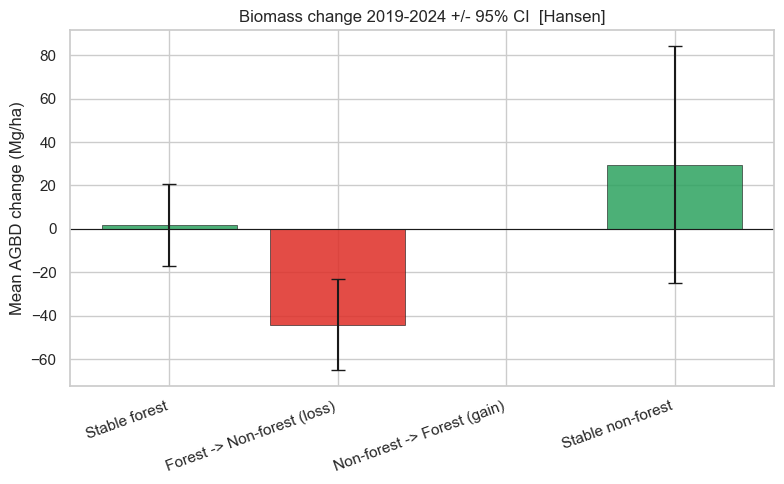

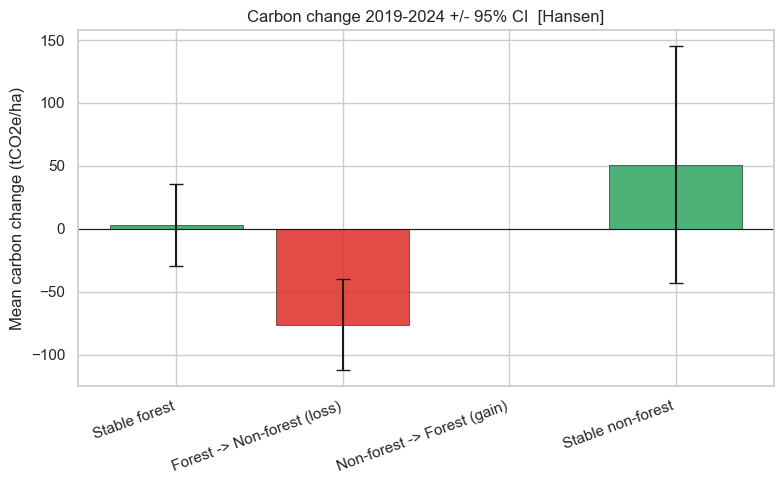

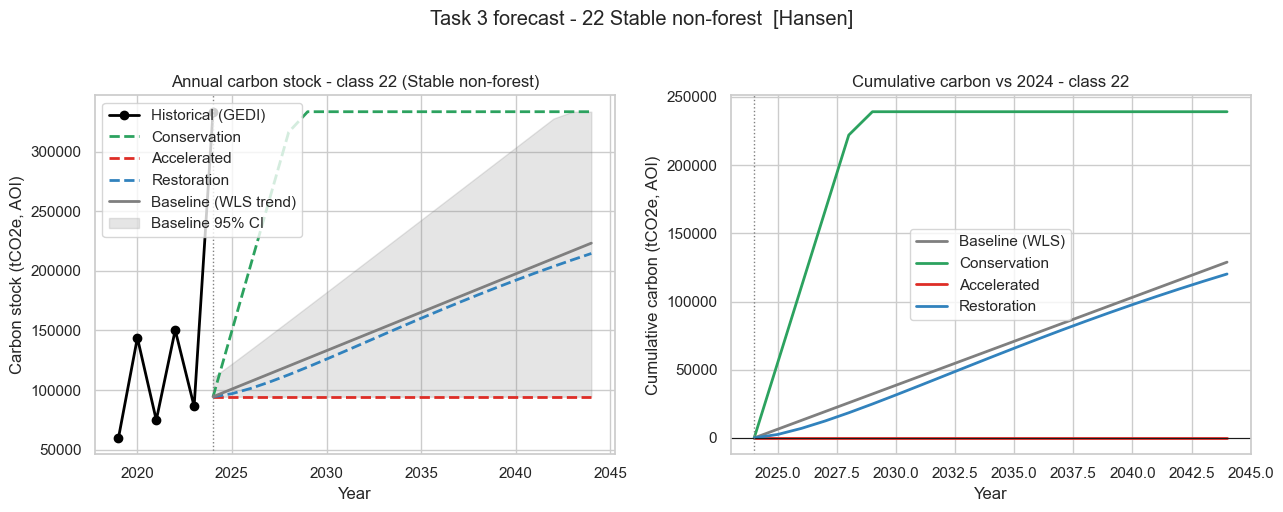

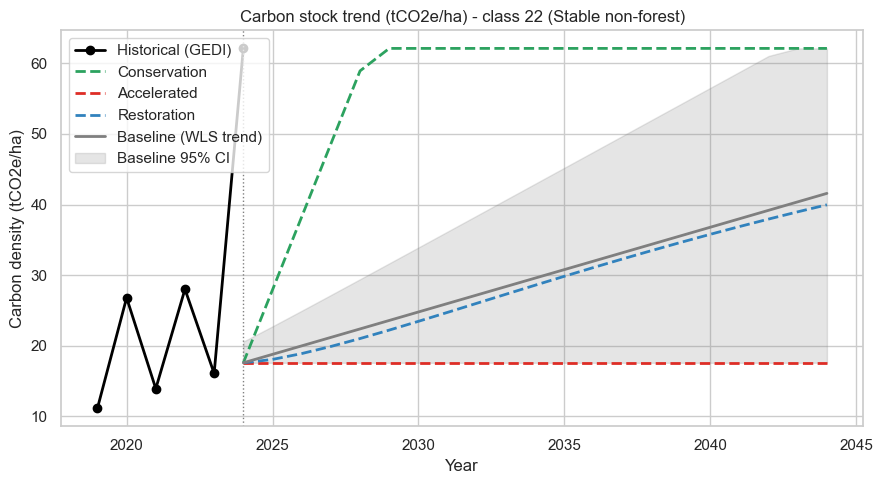


Done. Outputs in: output/biomass


In [82]:
# ------------------------------------------------------------------
# 6c) Charts: (a) change +/- 95% CI per class; (b) trend -> scenarios
# ------------------------------------------------------------------
# (a) Mean biomass CHANGE per class with 95% CI error bars
if not change_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(change_df))
    yv = change_df["agbd_change"].values
    err = 1.96 * change_df["change_se"].values
    colors = ["#2ca25f" if v >= 0 else "#de2d26" for v in yv]
    ax.bar(x, yv, yerr=err, capsize=5, color=colors, alpha=0.85, edgecolor="k", linewidth=0.5)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(change_df["stratum_label"], rotation=20, ha="right")
    ax.set_ylabel("Mean AGBD change (Mg/ha)")
    ax.set_title(f"Biomass change {CHANGE_YEARS[0]}-{CHANGE_YEARS[1]} +/- 95% CI  [{TRANSITION_SOURCE}]")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_BIOMASS_DIR, f"chart_change_ci_{TRANSITION_SOURCE}.png"), dpi=140)
    plt.show()

# (a1) Mean carbon CHANGE per class in tCO2e/ha with 95% CI  (= AGBD change x 0.47 x 44/12)
if not change_df.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(change_df))
    yv = change_df["co2e_change"].values
    err = 1.96 * change_df["co2e_change_se"].values
    colors = ["#2ca25f" if v >= 0 else "#de2d26" for v in yv]
    ax.bar(x, yv, yerr=err, capsize=5, color=colors, alpha=0.85, edgecolor="k", linewidth=0.5)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(change_df["stratum_label"], rotation=20, ha="right")
    ax.set_ylabel("Mean carbon change (tCO2e/ha)")
    ax.set_title(f"Carbon change {CHANGE_YEARS[0]}-{CHANGE_YEARS[1]} +/- 95% CI  [{TRANSITION_SOURCE}]")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_BIOMASS_DIR, f"chart_change_co2e_ci_{TRANSITION_SOURCE}.png"), dpi=140)
    plt.show()

# (b)+(c) TARGET transition: annual carbon STOCK and CUMULATIVE carbon, 3 scenarios
if not target_forecast.empty:
    area_t = target_forecast.attrs["area_ha"]
    hist_years = sorted(trend_df[trend_df["stratum"] == TARGET_TRANSITION]["year"].unique())
    hist_stock = [agbd_to_co2e(_class_density(trend_df, TARGET_TRANSITION, yr)) * area_t for yr in hist_years]
    sc_colors = {"Conservation": "#2ca25f", "Accelerated": "#de2d26", "Restoration": "#3182bd"}

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
    # (b) annual carbon stock (state) + historical
    if hist_years:
        axA.plot(hist_years, hist_stock, "o-", color="black", lw=2, label="Historical (GEDI)")
    for sc, col in sc_colors.items():
        axA.plot(target_forecast["year"], target_forecast[f"{sc}_tco2e"], "--", color=col, lw=2, label=sc)
    axA.plot(target_forecast["year"], target_forecast["Baseline_tco2e"], "-", color="#7f7f7f", lw=2, label="Baseline (WLS trend)")
    axA.fill_between(target_forecast["year"], target_forecast["Baseline_lo_tco2e"], target_forecast["Baseline_hi_tco2e"],
                     color="#7f7f7f", alpha=0.2, label="Baseline 95% CI")
    axA.axvline(STOCK_YEAR, color="grey", ls=":", lw=1)
    axA.set_title(f"Annual carbon stock - class {TARGET_TRANSITION} ({TARGET_LABEL})")
    axA.set_xlabel("Year"); axA.set_ylabel("Carbon stock (tCO2e, AOI)"); axA.legend()

    # (c) cumulative carbon vs the start year
    axB.plot(target_forecast["year"], target_forecast["Baseline_cum_tco2e"], "-", color="#7f7f7f", lw=2, label="Baseline (WLS)")
    for sc, col in sc_colors.items():
        axB.plot(target_forecast["year"], target_forecast[f"{sc}_cum_tco2e"], "-", color=col, lw=2, label=sc)
    axB.axhline(0, color="k", lw=0.8); axB.axvline(STOCK_YEAR, color="grey", ls=":", lw=1)
    axB.set_title(f"Cumulative carbon vs {STOCK_YEAR} - class {TARGET_TRANSITION}")
    axB.set_xlabel("Year"); axB.set_ylabel("Cumulative carbon (tCO2e, AOI)"); axB.legend()

    fig.suptitle(f"Task 3 forecast - {TARGET_TRANSITION} {TARGET_LABEL}  [{TRANSITION_SOURCE}]", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_BIOMASS_DIR,
                f"chart_target{TARGET_TRANSITION}_scenarios_{TRANSITION_SOURCE}.png"), dpi=140, bbox_inches="tight")
    plt.show()

# (b1) Carbon stock TREND per hectare (tCO2e/ha) with scenarios  (density; area-independent)
if not target_forecast.empty:
    hist_years = sorted(trend_df[trend_df["stratum"] == TARGET_TRANSITION]["year"].unique())
    hist_dens = [agbd_to_co2e(_class_density(trend_df, TARGET_TRANSITION, yr)) for yr in hist_years]
    sc_colors = {"Conservation": "#2ca25f", "Accelerated": "#de2d26", "Restoration": "#3182bd"}
    fig, ax = plt.subplots(figsize=(9, 5))
    if hist_years:
        ax.plot(hist_years, hist_dens, "o-", color="black", lw=2, label="Historical (GEDI)")
    for sc, col in sc_colors.items():
        ax.plot(target_forecast["year"], agbd_to_co2e(target_forecast[f"{sc}_agbd"]),
                "--", color=col, lw=2, label=sc)
    ax.plot(target_forecast["year"], agbd_to_co2e(target_forecast["Baseline_agbd"]),
            "-", color="#7f7f7f", lw=2, label="Baseline (WLS trend)")
    ax.fill_between(target_forecast["year"], agbd_to_co2e(target_forecast["Baseline_lo_agbd"]),
                    agbd_to_co2e(target_forecast["Baseline_hi_agbd"]), color="#7f7f7f", alpha=0.2, label="Baseline 95% CI")
    ax.axvline(STOCK_YEAR, color="grey", ls=":", lw=1)
    ax.set_title(f"Carbon stock trend (tCO2e/ha) - class {TARGET_TRANSITION} ({TARGET_LABEL})")
    ax.set_xlabel("Year"); ax.set_ylabel("Carbon density (tCO2e/ha)"); ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_BIOMASS_DIR,
                f"chart_target{TARGET_TRANSITION}_density_{TRANSITION_SOURCE}.png"), dpi=140)
    plt.show()

print("\nDone. Outputs in:", OUT_BIOMASS_DIR)


## Phase 7 — Task 5: VM0047 ex-ante ARR screening (GEDI carbon stock as baseline)

Merges the standalone **`ex_ante_tool/vm0047_screening_tool.py`** VM0047 Area-based engine (carbon
curve → deductions → buffer → net ERs, VM0047 Eq. 30) into this notebook, replacing its generic demo
species with parameters **fit directly to this AOI's GEDI record** from Phases 1-6:

| Role | Stratum (default) | Source |
|---|---|---|
| **Project area** | `EXANTE_PROJECT_CLASS` = 22, Stable non-forest | `AREAS_HA[22]` — land available for the ARR activity inside the AOI |
| **Growth calibration** | `EXANTE_CALIBRATION_CLASS` = 21, Non-forest → Forest gain | real multi-year GEDI trend of land *already regenerating inside the same AOI* |
| **Reference ceiling** | `EXANTE_REFERENCE_CLASS` = 11, Stable forest | mature-forest AGBD → tC/ha asymptote |

**Growth curve.** A `recovery_curve` species `C(t) = ref_C·(1 − e^{-rate·(t+adv)})` is fit by
nonlinear least squares (`scipy.optimize.curve_fit`, SE-weighted) to the calibration class's full
2019-2024 trend, anchored on the reference ceiling. `rate`/`adv` therefore reflect this AOI's actual
measured recovery, not IPCC literature defaults.

**Baseline (without-project).** The project class's *own* historical trend (`fit_trend`, same
`TREND_METHOD` as Phase 5) gives its real measured annual rate, clamped at ≥ 0 tCO2e/ha/yr — i.e. if
the "stable non-forest" land is itself already accumulating biomass (woody encroachment etc.), that
is conservatively treated as non-additional and subtracted from the project's gross removals every
year, exactly as VM0047 requires for an honest baseline.

**Deductions** follow VM0047 Eq. 30: uncertainty, Dynamic Performance Benchmark, leakage, and the
non-permanence buffer — same math as the standalone tool, just fed real numbers.

> One fix made when porting the engine: the original `Species.get_agb_per_ha` forced AGB to 0 at
> `age<=0` for *every* growth model, which is correct for bare-soil tree planting but wrong for
> `recovery_curve` land that already carries standing biomass at the start of the crediting period —
> it produced a one-year spike equal to the entire pre-existing stock. Fixed so `recovery_curve`
> alone evaluates `age=0` (existing stock today), so only genuine year-over-year growth is credited.

In [83]:
# ------------------------------------------------------------------
# 7a) VM0047 Area-based engine (adapted from ex_ante_tool/vm0047_screening_tool.py)
# ------------------------------------------------------------------
from dataclasses import dataclass, field
from typing import List, Dict, Tuple

@dataclass
class Species:
    """Tree species / regen cohort with growth and allometric parameters."""
    name: str
    scientific_name: str = ""
    species_type: str = "Fruit"
    planting_density: int = 900
    root_shoot_ratio: float = 0.27
    carbon_fraction: float = 0.47
    wood_density: float = 0.50
    mortality_rate_y1: float = 0.10
    annual_mortality: float = 0.01

    growth_model: str = "logistic"          # "logistic", "linear_dbh", "MAI", "lookup", "recovery_curve"

    agb_max: float = 150.0
    k_growth: float = 0.15
    age_inflection: float = 15.0

    # Recovery curve (natural regeneration toward a reference biomass stock):
    # C(t) = ref_biomass_stock * (1 - exp(-recovery_rate * (t + advancement_years)))
    ref_biomass_stock: float = 86.6
    recovery_rate: float = 0.04
    advancement_years: float = 0.0
    agc_adjustment: float = 0.0

    dbh_growth_rate: float = 0.0
    height_growth_rate: float = 0.0
    allometric_a: float = 0.0
    allometric_b: float = 0.0

    mai: float = 0.0
    agb_lookup: List[Tuple[int, float]] = field(default_factory=list)

    is_harvested: bool = False
    harvest_cycle_years: int = 30
    min_harvest_age: int = 15
    pct_harvested: float = 1.0
    bg_affected_by_harvest: bool = False

    area_fraction: float = 1.0

    def get_agb_per_ha(self, age: int) -> float:
        """Aboveground biomass (t DM / ha) at given age."""
        # recovery_curve is exempt from the age<=0 -> 0 short-circuit: that branch already carries
        # standing biomass at the start of the crediting period (see Phase 7 markdown for why).
        if age <= 0 and self.growth_model != "recovery_curve":
            return 0.0

        if self.growth_model == "logistic":
            return self.agb_max / (1.0 + math.exp(-self.k_growth * (age - self.age_inflection)))

        elif self.growth_model == "linear_dbh":
            dbh = self.dbh_growth_rate * age
            if dbh <= 0:
                return 0.0
            agb_per_tree_kg = self.allometric_a * (dbh ** self.allometric_b)
            surviving = self.planting_density * ((1 - self.mortality_rate_y1) if age == 1 else 1.0) * ((1 - self.annual_mortality) ** max(0, age - 1))
            return agb_per_tree_kg * surviving / 1000.0

        elif self.growth_model == "MAI":
            return self.mai * self.wood_density * age

        elif self.growth_model == "recovery_curve":
            effective_age = max(0, age) + self.advancement_years
            recovery_frac = 1.0 - math.exp(-self.recovery_rate * effective_age)
            agb_c = self.ref_biomass_stock * recovery_frac
            agb_dm = agb_c / self.carbon_fraction if self.carbon_fraction > 0 else 0.0
            agb_dm *= (1.0 - self.agc_adjustment)
            return agb_dm

        elif self.growth_model == "lookup" and self.agb_lookup:
            if age <= self.agb_lookup[0][0]:
                return self.agb_lookup[0][1]
            if age >= self.agb_lookup[-1][0]:
                return self.agb_lookup[-1][1]
            for i in range(len(self.agb_lookup) - 1):
                a0, v0 = self.agb_lookup[i]
                a1, v1 = self.agb_lookup[i + 1]
                if a0 <= age <= a1:
                    frac = (age - a0) / (a1 - a0) if a1 != a0 else 0
                    return v0 + frac * (v1 - v0)
            return 0.0

        return 0.0

    def get_carbon_stock_per_ha(self, age: int) -> Dict[str, float]:
        """Carbon stocks (t CO2e / ha) at given age. Returns AGB, BGB, total."""
        agb_dm = self.get_agb_per_ha(age)

        if self.is_harvested and age >= self.min_harvest_age:
            cycle_age = ((age - self.min_harvest_age) % self.harvest_cycle_years)
            if cycle_age == 0 and age > self.min_harvest_age:
                agb_dm = agb_dm * (1 - self.pct_harvested)
            else:
                effective_age = cycle_age if cycle_age > 0 else self.harvest_cycle_years
                agb_dm = self.get_agb_per_ha(effective_age)

        agb_c = agb_dm * self.carbon_fraction
        bgb_c = agb_c * self.root_shoot_ratio
        co2_factor = 44.0 / 12.0
        agb_co2 = agb_c * co2_factor
        bgb_co2 = bgb_c * co2_factor

        return {"agb_dm": agb_dm, "agb_co2": agb_co2, "bgb_co2": bgb_co2, "total_co2": agb_co2 + bgb_co2}


@dataclass
class CarbonPool:
    """Carbon pool inclusion flags per VM0047 Table 3."""
    ag_woody_biomass: bool = True
    bg_woody_biomass: bool = True
    ag_nonwoody_biomass: bool = False
    bg_nonwoody_biomass: bool = False
    deadwood: bool = False
    litter: bool = False
    soc: bool = False
    hwp: bool = False
    deadwood_factor: float = 0.01
    litter_factor: float = 0.01
    soc_rate: float = 0.0


@dataclass
class Deductions:
    """VM0047 deduction parameters (Eq. 30 and related)."""
    uncertainty_pct: float = 0.10
    performance_benchmark_pct: float = 0.03
    non_permanence_risk: float = 0.15
    leakage_pct: float = 0.0
    leakage_years: int = 40
    pe_fertilizer: float = 0.0
    pe_fossil_fuel: float = 0.0
    pe_burning: float = 0.0


@dataclass
class ProjectConfig:
    """Complete VM0047 project configuration."""
    project_name: str = "ARR PWC"
    country: str = "Kenya"
    start_year: int = 2025
    crediting_period: int = 60
    total_area_ha: float = 10000.0
    planting_schedule: Dict[int, float] = field(default_factory=dict)
    species: List[Species] = field(default_factory=list)
    pools: CarbonPool = field(default_factory=CarbonPool)
    deductions: Deductions = field(default_factory=Deductions)
    baseline_carbon_stock: float = 0.0   # baseline annual removals (tCO2e/yr, whole project area)

    def get_area_at_year(self, year_offset: int) -> float:
        return sum(v for k, v in self.planting_schedule.items() if k <= year_offset)


class VM0047Engine:
    """Core calculation engine implementing VM0047 Area-based quantification."""

    def __init__(self, config: ProjectConfig):
        self.config = config
        self.results = []

    def _carbon_stock_per_ha(self, age: int) -> Dict[str, float]:
        total_agb, total_bgb = 0.0, 0.0
        for sp in self.config.species:
            stocks = sp.get_carbon_stock_per_ha(age)
            total_agb += stocks["agb_co2"] * sp.area_fraction
            total_bgb += stocks["bgb_co2"] * sp.area_fraction

        dw = total_agb * self.config.pools.deadwood_factor if self.config.pools.deadwood else 0.0
        li = total_agb * self.config.pools.litter_factor if self.config.pools.litter else 0.0
        soc = self.config.pools.soc_rate * age if self.config.pools.soc else 0.0

        return {"agb_co2": total_agb, "bgb_co2": total_bgb, "deadwood_co2": dw, "litter_co2": li,
                "soc_co2": soc, "total_stock_co2": total_agb + total_bgb + dw + li + soc}

    def run(self) -> List[Dict]:
        cfg = self.config
        ded = cfg.deductions
        results = []
        prev_total_stock = 0.0

        for t in range(cfg.crediting_period + 1):
            cal_year = cfg.start_year + t
            total_project_stock = 0.0
            cohort_details = []

            for planting_year, area_planted in cfg.planting_schedule.items():
                age = t - planting_year
                # age<0 (not yet planted) is excluded; age==0 IS included so a recovery_curve
                # species' pre-existing stock at project start is counted (see fix above).
                if age < 0 or area_planted <= 0:
                    continue

                stock_per_ha = self._carbon_stock_per_ha(age)
                cohort_stock = stock_per_ha["total_stock_co2"] * area_planted
                total_project_stock += cohort_stock
                cohort_details.append({"planting_year": planting_year, "age": age, "area_ha": area_planted,
                                       "stock_per_ha": stock_per_ha["total_stock_co2"], "cohort_total": cohort_stock})

            delta_c_wp = total_project_stock - prev_total_stock if t > 0 else 0.0
            prev_total_stock = total_project_stock

            baseline_removals = cfg.baseline_carbon_stock
            gross_removals = max(0, delta_c_wp - baseline_removals)

            cumulative_area = cfg.get_area_at_year(t)
            pe_total = (ded.pe_fertilizer + ded.pe_fossil_fuel + ded.pe_burning) * cumulative_area

            if ded.leakage_years == 0 or t <= ded.leakage_years:
                leakage = gross_removals * ded.leakage_pct
            else:
                leakage = 0.0

            pb_deduction = gross_removals * ded.performance_benchmark_pct
            unc_deduction = gross_removals * ded.uncertainty_pct

            net_before_buffer = gross_removals - pe_total - leakage - pb_deduction - unc_deduction
            net_before_buffer = max(0, net_before_buffer)

            buffer_deduction = net_before_buffer * ded.non_permanence_risk
            net_ers = net_before_buffer - buffer_deduction
            er_per_ha = net_ers / cumulative_area if cumulative_area > 0 else 0.0

            results.append({
                "t": t, "calendar_year": cal_year, "cumulative_area_ha": cumulative_area,
                "total_carbon_stock_tco2": total_project_stock, "delta_c_wp_tco2": delta_c_wp,
                "gross_removals_tco2": gross_removals, "project_emissions_tco2": pe_total,
                "leakage_tco2": leakage, "pb_deduction_tco2": pb_deduction,
                "uncertainty_deduction_tco2": unc_deduction, "net_before_buffer_tco2": net_before_buffer,
                "buffer_deduction_tco2": buffer_deduction, "net_ers_tco2": net_ers,
                "er_per_ha_yr": er_per_ha, "cohort_details": cohort_details,
            })

        self.results = results
        return results

    def summary(self) -> Dict:
        if not self.results:
            self.run()
        total_gross = sum(r["gross_removals_tco2"] for r in self.results)
        total_net = sum(r["net_ers_tco2"] for r in self.results)
        total_pe = sum(r["project_emissions_tco2"] for r in self.results)
        total_leakage = sum(r["leakage_tco2"] for r in self.results)
        total_buffer = sum(r["buffer_deduction_tco2"] for r in self.results)
        total_unc = sum(r["uncertainty_deduction_tco2"] for r in self.results)
        total_pb = sum(r["pb_deduction_tco2"] for r in self.results)
        years_active = len([r for r in self.results if r["net_ers_tco2"] > 0])
        avg_annual = total_net / years_active if years_active > 0 else 0
        max_area = max(r["cumulative_area_ha"] for r in self.results)
        er_ha_yr = total_net / (max_area * self.config.crediting_period) if max_area > 0 else 0
        return {
            "project_name": self.config.project_name, "total_area_ha": max_area,
            "crediting_period": self.config.crediting_period, "total_gross_removals": total_gross,
            "total_net_ers": total_net, "total_project_emissions": total_pe,
            "total_leakage": total_leakage, "total_uncertainty_ded": total_unc,
            "total_pb_ded": total_pb, "total_buffer": total_buffer, "avg_annual_ers": avg_annual,
            "er_per_ha_per_yr": er_ha_yr,
            "deduction_pct": (1 - total_net / total_gross) * 100 if total_gross > 0 else 0,
        }

print("VM0047 engine ready (Species, CarbonPool, Deductions, ProjectConfig, VM0047Engine).")


VM0047 engine ready (Species, CarbonPool, Deductions, ProjectConfig, VM0047Engine).


In [92]:
# ------------------------------------------------------------------
# 7b) Calibrate the recovery curve + baseline rate from REAL GEDI data, run the engine
# ------------------------------------------------------------------
# ---- Stratum roles (override here if your project boundary differs from the defaults) ----
EXANTE_PROJECT_CLASS      = 22     # area to be afforested -> ProjectConfig.total_area_ha
EXANTE_CALIBRATION_CLASS  = 21     # already-regenerating land -> fits the recovery curve
EXANTE_REFERENCE_CLASS    = 11     # mature forest -> recovery-curve ceiling
EXANTE_PROJECT_AREA_HA_OVERRIDE = 100   # set a number to override AREAS_HA[EXANTE_PROJECT_CLASS]
EXANTE_BASELINE_RATE_OVERRIDE   = None   # set a tCO2e/ha/yr number to override the fitted baseline rate

EXANTE_START_YEAR        = STOCK_YEAR    # ex-ante t=0 = latest GEDI observation year
EXANTE_CREDITING_PERIOD  = 40            # VCS/VM0047 standard ARR crediting period (years)
EXANTE_ROOT_SHOOT_RATIO  = 0.27          # IPCC default R:S, tropical broadleaf regrowth
EXANTE_CONSERVATIVE_HAIRCUT = 0.0        # extra proportional haircut on the calibrated curve (0 = none;
                                          # the deductions below already add VM0047 conservativeness)
EXANTE_OUTPUT_XLSX = os.path.join(OUT_BIOMASS_DIR, f"VM0047_ExAnte_Screening_{TRANSITION_SOURCE}.xlsx")

def calibrate_recovery_curve(trend_df, calibration_class, reference_class, stock_year):
    """Fit C(t) = ref_C*(1-exp(-rate*(t+adv))) to the REAL GEDI trend of `calibration_class`,
    anchored on the mature-forest ceiling (`ref_C`, tC/ha) from `reference_class`."""
    ref_agbd = _class_density(trend_df, reference_class, stock_year)
    ref_c = ref_agbd * CARBON_FRACTION

    sub = trend_df[trend_df["stratum"] == calibration_class].sort_values("year")
    years = sub["year"].values.astype(float)
    agbd = sub["agbd_mean"].values.astype(float)
    se = sub["agbd_se"].values.astype(float)
    t0 = years.min() if years.size else float(stock_year)
    t_rel = years - t0

    def model(t, rate, adv):
        return (ref_c * (1.0 - np.exp(-rate * (t + adv)))) / CARBON_FRACTION

    rate_fit, adv_fit, fit_ok = 0.04, 5.0, False
    try:
        from scipy.optimize import curve_fit
        pos = se[(np.isfinite(se)) & (se > 0)]
        fill = float(np.median(pos)) if pos.size else 1.0
        sigma = np.where(np.isfinite(se) & (se > 0), se, fill)
        popt, _ = curve_fit(model, t_rel, agbd, p0=[0.04, 5.0],
                            bounds=([1e-3, 0.0], [1.0, 50.0]), sigma=sigma, maxfev=5000)
        rate_fit, adv_fit, fit_ok = float(popt[0]), float(popt[1]), True
    except Exception as e:
        logging.warning("Recovery-curve fit failed (%s); using fallback rate=%.2f, adv=%.1f", e, rate_fit, adv_fit)

    fitted = model(t_rel, rate_fit, adv_fit) if years.size else np.array([])
    rmse = float(np.sqrt(np.mean((agbd - fitted) ** 2))) if years.size else float("nan")
    return dict(ref_c_tC_ha=ref_c, ref_agbd=ref_agbd, recovery_rate=rate_fit, advancement_years=adv_fit,
                fit_ok=fit_ok, t0=t0, years=years, agbd_obs=agbd, agbd_fit=fitted, rmse=rmse)

exante_engine, exante_config, exante_calib, exante_scenarios = None, None, None, []

if not trend_df.empty:
    exante_calib = calibrate_recovery_curve(trend_df, EXANTE_CALIBRATION_CLASS, EXANTE_REFERENCE_CLASS, STOCK_YEAR)

    project_area_ha = EXANTE_PROJECT_AREA_HA_OVERRIDE or AREAS_HA.get(EXANTE_PROJECT_CLASS, 0.0)

    # Baseline = the project class's OWN historical trend (robust WLS fit, same TREND_METHOD as
    # Phase 5), clamped >= 0: a non-forest baseline that is itself gaining biomass is conservatively
    # treated as non-additional and deducted every year.
    sub_base = trend_df[trend_df["stratum"] == EXANTE_PROJECT_CLASS].sort_values("year")
    base_fit = fit_trend(sub_base["year"].values, sub_base["agbd_mean"].values, sub_base["agbd_se"].values,
                         EXANTE_START_YEAR, TREND_METHOD)
    base_rate_co2e_ha = EXANTE_BASELINE_RATE_OVERRIDE
    if base_rate_co2e_ha is None:
        base_rate_co2e_ha = max(0.0, agbd_to_co2e(base_fit["slope"]))

    exante_species = Species(
        name=f"GEDI-calibrated recovery (class {EXANTE_CALIBRATION_CLASS} -> ceiling class {EXANTE_REFERENCE_CLASS})",
        scientific_name="Mixed AOI native regeneration", species_type="Native/Regeneration",
        planting_density=0, root_shoot_ratio=EXANTE_ROOT_SHOOT_RATIO, carbon_fraction=CARBON_FRACTION,
        growth_model="recovery_curve", ref_biomass_stock=exante_calib["ref_c_tC_ha"],
        recovery_rate=exante_calib["recovery_rate"], advancement_years=exante_calib["advancement_years"],
        agc_adjustment=EXANTE_CONSERVATIVE_HAIRCUT, is_harvested=False, area_fraction=1.0,
    )

    exante_config = ProjectConfig(
        project_name=f"{TRANSITION_SOURCE} ARR ex-ante (GEDI-calibrated, class {EXANTE_PROJECT_CLASS})",
        country="", start_year=EXANTE_START_YEAR, crediting_period=EXANTE_CREDITING_PERIOD,
        total_area_ha=project_area_ha, planting_schedule={0: project_area_ha},
        species=[exante_species], pools=CarbonPool(ag_woody_biomass=True, bg_woody_biomass=True),
        deductions=Deductions(uncertainty_pct=0.10, performance_benchmark_pct=0.03,
                              non_permanence_risk=0.15, leakage_pct=0.0, leakage_years=EXANTE_CREDITING_PERIOD),
        baseline_carbon_stock=base_rate_co2e_ha * project_area_ha,
    )

    exante_engine = VM0047Engine(exante_config)
    exante_engine.run()
    exante_summary = exante_engine.summary()

    print(f"Calibration (class {EXANTE_CALIBRATION_CLASS} -> ceiling class {EXANTE_REFERENCE_CLASS}, fit_ok={exante_calib['fit_ok']}):")
    print(f"  ref ceiling   = {exante_calib['ref_agbd']:.1f} Mg DM/ha ({exante_calib['ref_c_tC_ha']:.1f} tC/ha)")
    print(f"  recovery_rate = {exante_calib['recovery_rate']:.4f} /yr | advancement_years = {exante_calib['advancement_years']:.1f} | RMSE = {exante_calib['rmse']:.2f} Mg/ha")
    print(f"\nBaseline (class {EXANTE_PROJECT_CLASS}, {TREND_METHOD} trend): "
          f"{base_fit['slope']:.3f} Mg/ha/yr -> {base_rate_co2e_ha:.3f} tCO2e/ha/yr (clamped >= 0, override={EXANTE_BASELINE_RATE_OVERRIDE})")
    print(f"Project area: {project_area_ha:,.1f} ha | start year {EXANTE_START_YEAR} | crediting period {EXANTE_CREDITING_PERIOD} yr")
    print("\nVM0047 EX-ANTE SCREENING SUMMARY:")
    for k, v in exante_summary.items():
        print(f"  {k:28s}: {v:,.2f}" if isinstance(v, float) else f"  {k:28s}: {v}")

    exante_er_df = pd.DataFrame(exante_engine.results).drop(columns=["cohort_details"])
    display(exante_er_df)
else:
    print("No trend data; VM0047 ex-ante screening skipped.")


Calibration (class 21 -> ceiling class 11, fit_ok=True):
  ref ceiling   = 18.4 Mg DM/ha (8.6 tC/ha)
  recovery_rate = 0.0414 /yr | advancement_years = 1.4 | RMSE = 0.00 Mg/ha

Baseline (class 22, wls trend): 0.697 Mg/ha/yr -> 1.200 tCO2e/ha/yr (clamped >= 0, override=None)
Project area: 100.0 ha | start year 2024 | crediting period 40 yr

VM0047 EX-ANTE SCREENING SUMMARY:
  project_name                : Hansen ARR ex-ante (GEDI-calibrated, class 22)
  total_area_ha               : 100
  crediting_period            : 40
  total_gross_removals        : 113.73
  total_net_ers               : 84.10
  total_project_emissions     : 0.00
  total_leakage               : 0.00
  total_uncertainty_ded       : 11.37
  total_pb_ded                : 3.41
  total_buffer                : 14.84
  avg_annual_ers              : 14.02
  er_per_ha_per_yr            : 0.02
  deduction_pct               : 26.05


C:\Users\bandr\AppData\Local\Temp\ipykernel_25760\63167650.py:40: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(model, t_rel, agbd, p0=[0.04, 5.0],


,t,calendar_year,cumulative_area_ha,total_carbon_stock_tco2,delta_c_wp_tco2,gross_removals_tco2,project_emissions_tco2,leakage_tco2,pb_deduction_tco2,uncertainty_deduction_tco2,net_before_buffer_tco2,buffer_deduction_tco2,net_ers_tco2,er_per_ha_yr
0,0,2024,100,232.416457,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2025,100,386.177015,153.760558,33.727606,0.0,0.0,1.011828,3.372761,29.343017,4.401453,24.941564,0.249416
2,2,2026,100,533.701092,147.524077,27.491125,0.0,0.0,0.824734,2.749113,23.917279,3.587592,20.329687,0.203297
3,3,2027,100,675.241639,141.540547,21.507595,0.0,0.0,0.645228,2.150759,18.711607,2.806741,15.904866,0.159049
4,4,2028,100,811.041346,135.799706,15.766754,0.0,0.0,0.473003,1.576675,13.717076,2.057561,11.659515,0.116595
5,5,2029,100,941.333058,130.291713,10.258760,0.0,0.0,0.307763,1.025876,8.925122,1.338768,7.586353,0.075864
6,6,2030,100,1066.340180,125.007121,4.974169,0.0,0.0,0.149225,0.497417,4.327527,0.649129,3.678398,0.036784
7,7,2031,100,1186.277051,119.936872,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,8,2032,100,1301.349321,115.072269,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,9,2033,100,1411.754295,110.404974,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [93]:
# ------------------------------------------------------------------
# 7c) Scenario comparison: Base / Conservative / Optimistic (recovery-curve aware)
# ------------------------------------------------------------------
def build_exante_scenarios(base_config):
    import copy
    scenarios = []

    eng_base = VM0047Engine(base_config); eng_base.run()
    scenarios.append(("Base Case", eng_base))

    cfg_cons = copy.deepcopy(base_config)
    cfg_cons.project_name += " - Conservative"
    cfg_cons.deductions.uncertainty_pct = min(0.30, cfg_cons.deductions.uncertainty_pct * 1.5)
    cfg_cons.deductions.non_permanence_risk = min(0.30, cfg_cons.deductions.non_permanence_risk * 1.3)
    cfg_cons.deductions.leakage_pct = max(cfg_cons.deductions.leakage_pct, 0.05)
    for sp in cfg_cons.species:
        sp.recovery_rate *= 0.75
        sp.ref_biomass_stock *= 0.90
    eng_cons = VM0047Engine(cfg_cons); eng_cons.run()
    scenarios.append(("Conservative", eng_cons))

    cfg_opt = copy.deepcopy(base_config)
    cfg_opt.project_name += " - Optimistic"
    cfg_opt.deductions.uncertainty_pct *= 0.5
    cfg_opt.deductions.non_permanence_risk *= 0.7
    cfg_opt.deductions.leakage_pct = 0.0
    for sp in cfg_opt.species:
        sp.recovery_rate *= 1.15
    eng_opt = VM0047Engine(cfg_opt); eng_opt.run()
    scenarios.append(("Optimistic", eng_opt))

    return scenarios

if exante_config is not None:
    exante_scenarios = build_exante_scenarios(exante_config)
    print(f"{'Scenario':<16} {'Net ERs (tCO2e)':>18} {'ER/ha/yr':>12} {'Deduction %':>12}")
    print("-" * 60)
    for name, eng in exante_scenarios:
        s = eng.summary()
        print(f"{name:<16} {s['total_net_ers']:>18,.0f} {s['er_per_ha_per_yr']:>12.3f} {s['deduction_pct']:>11.1f}%")


Scenario            Net ERs (tCO2e)     ER/ha/yr  Deduction %
------------------------------------------------------------
Base Case                        84        0.021        26.1%
Conservative                      0        0.000         0.0%
Optimistic                      189        0.047        17.7%


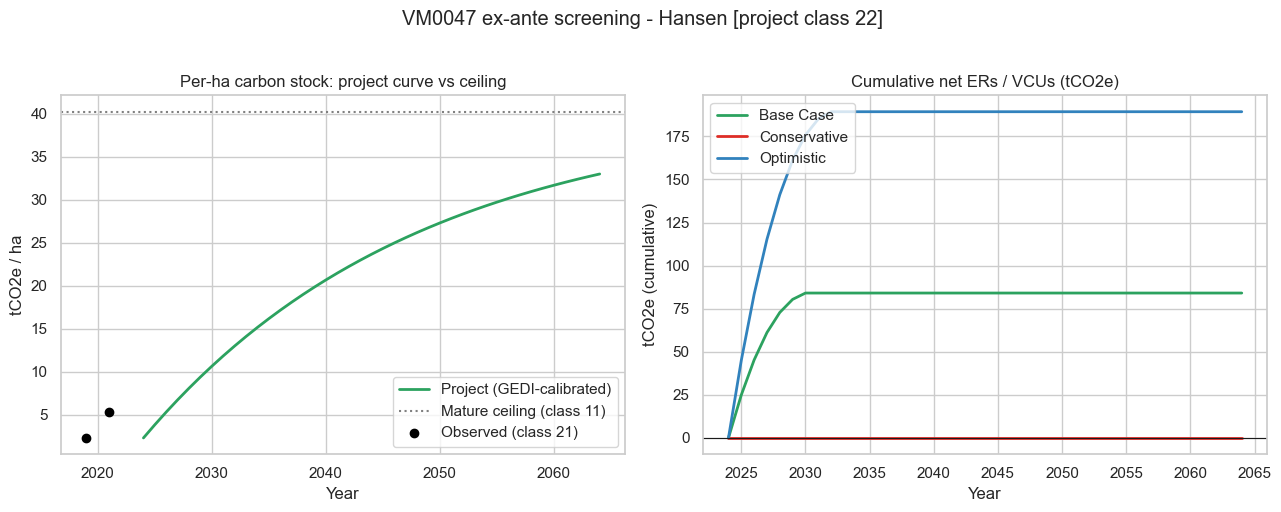

In [94]:
# ------------------------------------------------------------------
# 7d) Charts: per-ha recovery curve vs ceiling, and annual/cumulative net ERs by scenario
# ------------------------------------------------------------------
if exante_engine is not None:
    sp = exante_config.species[0]
    ages = np.arange(0, EXANTE_CREDITING_PERIOD + 1)
    curve_co2e_ha = [sp.get_carbon_stock_per_ha(int(a))["total_co2"] for a in ages]
    ceiling_co2e_ha = agbd_to_co2e(exante_calib["ref_agbd"]) * (1 + EXANTE_ROOT_SHOOT_RATIO)

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))
    axA.plot(EXANTE_START_YEAR + ages, curve_co2e_ha, "-", color="#2ca25f", lw=2, label="Project (GEDI-calibrated)")
    axA.axhline(ceiling_co2e_ha, color="grey", ls=":", lw=1.5, label=f"Mature ceiling (class {EXANTE_REFERENCE_CLASS})")
    axA.scatter(exante_calib["years"], agbd_to_co2e(exante_calib["agbd_obs"]) * (1 + EXANTE_ROOT_SHOOT_RATIO),
               color="black", zorder=5, label=f"Observed (class {EXANTE_CALIBRATION_CLASS})")
    axA.set_title("Per-ha carbon stock: project curve vs ceiling"); axA.set_xlabel("Year"); axA.set_ylabel("tCO2e / ha"); axA.legend()

    sc_colors = {"Base Case": "#2ca25f", "Conservative": "#de2d26", "Optimistic": "#3182bd"}
    for name, eng in exante_scenarios:
        df = pd.DataFrame(eng.results)
        axB.plot(df["calendar_year"], df["net_ers_tco2"].cumsum(), "-", color=sc_colors.get(name, "grey"), lw=2, label=name)
    axB.axhline(0, color="k", lw=0.8)
    axB.set_title("Cumulative net ERs / VCUs (tCO2e)"); axB.set_xlabel("Year"); axB.set_ylabel("tCO2e (cumulative)"); axB.legend()

    fig.suptitle(f"VM0047 ex-ante screening - {TRANSITION_SOURCE} [project class {EXANTE_PROJECT_CLASS}]", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_BIOMASS_DIR, f"chart_exante_screening_{TRANSITION_SOURCE}.png"), dpi=140, bbox_inches="tight")
    plt.show()


In [95]:
# ------------------------------------------------------------------
# 7e) Excel export (same workbook layout as the standalone screening tool)
# ------------------------------------------------------------------
def write_excel(engine, filepath, scenarios=None):
    """Write screening results to an Excel workbook (Project Parameters, Carbon Curve,
    ER Projections, Summary, Scenario Comparison, Cohort Analysis)."""
    from openpyxl import Workbook
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.chart import LineChart, Reference
    from openpyxl.utils import get_column_letter

    wb = Workbook()
    header_font = Font(name="Arial", bold=True, size=11, color="FFFFFF")
    header_fill = PatternFill("solid", fgColor="2F5233")
    input_font = Font(name="Arial", color="0000FF", size=10)
    formula_font = Font(name="Arial", color="000000", size=10)
    num_fmt = "#,##0"
    num_fmt_dec = "#,##0.00"
    thin_border = Border(left=Side(style="thin"), right=Side(style="thin"),
                         top=Side(style="thin"), bottom=Side(style="thin"))

    def style_header(ws, row, max_col):
        for c in range(1, max_col + 1):
            cell = ws.cell(row=row, column=c)
            cell.font = header_font; cell.fill = header_fill
            cell.alignment = Alignment(horizontal="center", wrap_text=True); cell.border = thin_border

    def style_data(ws, row, max_col, is_input=False):
        for c in range(1, max_col + 1):
            cell = ws.cell(row=row, column=c)
            cell.font = input_font if is_input else formula_font
            cell.border = thin_border; cell.alignment = Alignment(horizontal="right")

    cfg = engine.config

    # Sheet 1: Project Parameters
    ws_params = wb.active; ws_params.title = "Project Parameters"
    params_data = [
        ("VM0047 EX-ANTE PROJECT PARAMETERS", "", ""), ("", "", ""),
        ("GENERAL", "", ""),
        ("Project Name", cfg.project_name, ""),
        ("Start Year", cfg.start_year, ""),
        ("Crediting Period (years)", cfg.crediting_period, ""),
        ("Total Project Area (ha)", cfg.total_area_ha, ""),
        ("Baseline Removals (tCO2e/yr, whole area)", round(cfg.baseline_carbon_stock, 2), ""),
        ("", "", ""),
        ("DEDUCTIONS (VM0047 Eq. 30)", "Value", "Notes"),
        ("Uncertainty (UNC_t)", cfg.deductions.uncertainty_pct, "Ex-ante minimum 10%"),
        ("Performance Benchmark (PB_t)", cfg.deductions.performance_benchmark_pct, "Dynamic Performance Benchmark"),
        ("Non-Permanence Risk (NPR)", cfg.deductions.non_permanence_risk, "Buffer pool contribution"),
        ("Leakage", cfg.deductions.leakage_pct, "Activity-shifting leakage"),
        ("", "", ""),
        ("SPECIES (GEDI-calibrated)", "", ""),
    ]
    for sp in cfg.species:
        params_data += [
            ("Name", sp.name, ""), ("Growth model", sp.growth_model, ""),
            ("Reference biomass (tC/ha)", round(sp.ref_biomass_stock, 2), ""),
            ("Recovery rate (/yr)", round(sp.recovery_rate, 4), ""),
            ("Advancement years", round(sp.advancement_years, 2), ""),
            ("Root:shoot ratio", sp.root_shoot_ratio, ""), ("Carbon fraction", sp.carbon_fraction, ""),
        ]
    for r_idx, row_data in enumerate(params_data, 1):
        for c_idx, val in enumerate(row_data, 1):
            ws_params.cell(row=r_idx, column=c_idx, value=val)
    ws_params.cell(1, 1).font = Font(name="Arial", bold=True, size=14, color="2F5233")
    ws_params.column_dimensions["A"].width = 38; ws_params.column_dimensions["B"].width = 28; ws_params.column_dimensions["C"].width = 30

    # Sheet 2: Carbon Curve (per-ha)
    ws_curve = wb.create_sheet("Carbon Curve")
    headers_curve = ["Age (yr)", "AGB (tCO2e/ha)", "BGB (tCO2e/ha)", "Total Stock (tCO2e/ha)", "Annual Change (tCO2e/ha/yr)"]
    for c, h in enumerate(headers_curve, 1):
        ws_curve.cell(1, c, h)
    style_header(ws_curve, 1, len(headers_curve))
    prev_stock = 0.0
    for age in range(0, cfg.crediting_period + 1):
        row = age + 2
        stocks = engine._carbon_stock_per_ha(age)
        total = stocks["total_stock_co2"]; annual_change = total - prev_stock; prev_stock = total
        ws_curve.cell(row, 1, age); ws_curve.cell(row, 2, round(stocks["agb_co2"], 4))
        ws_curve.cell(row, 3, round(stocks["bgb_co2"], 4)); ws_curve.cell(row, 4, round(total, 4))
        ws_curve.cell(row, 5, round(annual_change, 4))
        style_data(ws_curve, row, len(headers_curve))
    max_row = cfg.crediting_period + 2
    chart = LineChart(); chart.title = "Carbon Accumulation Curve (tCO2e/ha)"; chart.y_axis.title = "tCO2e / ha"
    chart.x_axis.title = "Age (years)"; chart.style = 10; chart.width = 22; chart.height = 14
    data_ref = Reference(ws_curve, min_col=4, min_row=1, max_row=max_row)
    cats = Reference(ws_curve, min_col=1, min_row=2, max_row=max_row)
    chart.add_data(data_ref, titles_from_data=True); chart.set_categories(cats)
    chart.series[0].graphicalProperties.line.width = 25000
    ws_curve.add_chart(chart, "G2")
    for c in range(1, 6):
        ws_curve.column_dimensions[get_column_letter(c)].width = 18

    # Sheet 3: ER Projections
    ws_er = wb.create_sheet("ER Projections")
    headers_er = ["t", "Calendar Year", "Cumulative Area (ha)", "Total C Stock (tCO2e)", "Delta C_WP,t (tCO2e)",
                 "Gross Removals (tCO2e)", "Project Emissions (tCO2e)", "Leakage (tCO2e)", "PB Deduction (tCO2e)",
                 "Uncertainty Ded. (tCO2e)", "Net Before Buffer (tCO2e)", "Buffer (tCO2e)", "Net ERs / VCUs (tCO2e)", "ER per ha per yr"]
    for c, h in enumerate(headers_er, 1):
        ws_er.cell(1, c, h)
    style_header(ws_er, 1, len(headers_er))
    results = engine.results if engine.results else engine.run()
    for i, r in enumerate(results):
        row = i + 2
        vals = [r["t"], r["calendar_year"], r["cumulative_area_ha"], round(r["total_carbon_stock_tco2"], 2),
               round(r["delta_c_wp_tco2"], 2), round(r["gross_removals_tco2"], 2), round(r["project_emissions_tco2"], 2),
               round(r["leakage_tco2"], 2), round(r["pb_deduction_tco2"], 2), round(r["uncertainty_deduction_tco2"], 2),
               round(r["net_before_buffer_tco2"], 2), round(r["buffer_deduction_tco2"], 2), round(r["net_ers_tco2"], 2),
               round(r["er_per_ha_yr"], 4)]
        for c, v in enumerate(vals, 1):
            ws_er.cell(row, c, v)
        style_data(ws_er, row, len(headers_er))
    for row in range(2, len(results) + 2):
        for c in range(3, 14):
            ws_er.cell(row, c).number_format = num_fmt
        ws_er.cell(row, 14).number_format = num_fmt_dec
    sum_row = len(results) + 3
    ws_er.cell(sum_row, 1, "TOTAL"); ws_er.cell(sum_row, 1).font = Font(name="Arial", bold=True, size=11)
    for c in [6, 7, 8, 9, 10, 11, 12, 13]:
        col_letter = get_column_letter(c)
        ws_er.cell(sum_row, c, f"=SUM({col_letter}2:{col_letter}{len(results)+1})")
        ws_er.cell(sum_row, c).font = Font(name="Arial", bold=True); ws_er.cell(sum_row, c).number_format = num_fmt
    for c in range(1, 15):
        ws_er.column_dimensions[get_column_letter(c)].width = 18
    max_er_row = len(results) + 1
    chart3 = LineChart(); chart3.title = "Annual Net ERs (tCO2e)"; chart3.y_axis.title = "tCO2e"
    chart3.x_axis.title = "Calendar Year"; chart3.style = 10; chart3.width = 22; chart3.height = 14
    data_ref3 = Reference(ws_er, min_col=13, min_row=1, max_row=max_er_row)
    cats3 = Reference(ws_er, min_col=2, min_row=2, max_row=max_er_row)
    chart3.add_data(data_ref3, titles_from_data=True); chart3.set_categories(cats3)
    chart3.series[0].graphicalProperties.line.width = 25000
    ws_er.add_chart(chart3, "P2")

    # Sheet 4: Summary
    ws_sum = wb.create_sheet("Summary"); smry = engine.summary()
    summary_rows = [
        ("VM0047 EX-ANTE SCREENING SUMMARY", ""), ("", ""),
        ("Project", smry["project_name"]), ("Total Area (ha)", smry["total_area_ha"]),
        ("Crediting Period (years)", smry["crediting_period"]), ("", ""),
        ("EMISSION REDUCTIONS", ""),
        ("Total Gross Removals (tCO2e)", round(smry["total_gross_removals"], 0)),
        ("Total Project Emissions (tCO2e)", round(smry["total_project_emissions"], 0)),
        ("Total Leakage (tCO2e)", round(smry["total_leakage"], 0)),
        ("Total Uncertainty Deduction (tCO2e)", round(smry["total_uncertainty_ded"], 0)),
        ("Total PB Deduction (tCO2e)", round(smry["total_pb_ded"], 0)),
        ("Total Buffer Contribution (tCO2e)", round(smry["total_buffer"], 0)),
        ("Total Net ERs / VCUs (tCO2e)", round(smry["total_net_ers"], 0)), ("", ""),
        ("PERFORMANCE METRICS", ""),
        ("Average Annual ERs (tCO2e/yr)", round(smry["avg_annual_ers"], 0)),
        ("ER per ha per year (tCO2e/ha/yr)", round(smry["er_per_ha_per_yr"], 4)),
        ("Total Deduction Rate (%)", round(smry["deduction_pct"], 1)),
    ]
    for r_idx, (label, val) in enumerate(summary_rows, 1):
        ws_sum.cell(r_idx, 1, label); ws_sum.cell(r_idx, 2, val)
    ws_sum.cell(1, 1).font = Font(name="Arial", bold=True, size=14, color="2F5233")
    ws_sum.column_dimensions["A"].width = 40; ws_sum.column_dimensions["B"].width = 20

    # Sheet 5: Scenario Comparison
    if scenarios:
        ws_scen = wb.create_sheet("Scenario Comparison")
        scen_headers = ["Metric"] + [name for name, _ in scenarios]
        for c, h in enumerate(scen_headers, 1):
            ws_scen.cell(1, c, h)
        style_header(ws_scen, 1, len(scen_headers))
        metrics = [("Total Area (ha)", "total_area_ha"), ("Crediting Period (yr)", "crediting_period"),
                  ("Total Gross Removals (tCO2e)", "total_gross_removals"), ("Total Net ERs (tCO2e)", "total_net_ers"),
                  ("Avg Annual ERs (tCO2e/yr)", "avg_annual_ers"), ("ER per ha per yr", "er_per_ha_per_yr"),
                  ("Deduction Rate (%)", "deduction_pct")]
        for r_idx, (label, key) in enumerate(metrics, 2):
            ws_scen.cell(r_idx, 1, label); ws_scen.cell(r_idx, 1).font = Font(name="Arial", bold=True)
            for c_idx, (_, eng) in enumerate(scenarios, 2):
                val = eng.summary().get(key, 0)
                ws_scen.cell(r_idx, c_idx, round(val, 4) if isinstance(val, float) else val)
                style_data(ws_scen, r_idx, len(scen_headers))
        ws_scen.column_dimensions["A"].width = 35
        for c in range(2, len(scen_headers) + 1):
            ws_scen.column_dimensions[get_column_letter(c)].width = 22

    wb.save(filepath)
    return filepath

if exante_engine is not None:
    try:
        write_excel(exante_engine, EXANTE_OUTPUT_XLSX, scenarios=exante_scenarios)
        print("Wrote:", EXANTE_OUTPUT_XLSX)
    except ImportError as e:
        print(f"Skipped Excel export (missing dependency: {e}).")


Wrote: output/biomass\VM0047_ExAnte_Screening_Hansen.xlsx
